In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('../src/')

In [2]:
import utils
import importlib
importlib.reload(utils)

<module 'utils' from '/run/media/brokrab/96FCEB53FCEB2C65/Linux_Wind_Shared/GalaxyFormation_FullProject/Notebooks/../src/utils.py'>

In [3]:
h = 0.67 

Om_m = 0.315            # matter density
Om_b = 0.022/(h*h)      # baryonic matter density
Om_lambda = 0.685       # vacuum energy density

rho_c = 2.78e11 *h*h    # in units of M_s/Mpc^3

# mean matter density of the universe
rho_0 = Om_m * rho_c    # in units of M_s/Mpc^3
delta_c = 1.686         # Critical density for spherical collapse

# for normalising the power spectrum
sigma8_obs = 0.811      # Observed value of sigma_8
n = 0.965               # power spectrum P(k)~ k^n

z_range = np.linspace(0.1,20, 100)

from numba import jit

f_b = Om_b/Om_m     # fraction of baryonic matter
H0 = h/9.78e9         # in units of 1/yr

# Full $\sigma(E,z)$ Calculation

In [4]:
def x_FullSigma(E, E_0, y_0):
    return E / E_0 - y_0

def y_FullSigma(E, E_0, y_0, y_1):
    return np.sqrt(x_FullSigma(E, E_0, y_0) ** 2 + y_1 ** 2)

def F_FullSigma(E, E_0, y_0, y_1, y_w, P, y_a):
    return ((x_FullSigma(E, E_0, y_0) - 1) ** 2 + y_w ** 2) * y_FullSigma(E, E_0, y_0, y_1) ** (0.5 * P - 5.5) * (1 + np.sqrt(y_FullSigma(E, E_0, y_0, y_1) / y_a)) ** (-P)

def sigma_FullSigma(E, E_0, y_0, y_1, y_w, P, y_a, sigma_0):
    return sigma_0 * F_FullSigma(E, E_0, y_0, y_1, y_w, P, y_a)

In [5]:
E_val = 1 #keV

#For H_I:
E_0_HI = 0.4298 * 10 ** (-3)
y_0_HI = 0
y_1_HI = 0
y_w_HI = 0
P_HI = 2.963
y_a_HI = 32.88
sigma_0_HI = 5.475 * 10 ** (-14)

#For He_I:
E_0_HeI = 13.61 * 10 ** (-3)
y_0_HeI = 0.4434
y_1_HeI = 2.136
y_w_HeI = 2.039
P_HeI = 3.188
y_a_HeI = 1.469
sigma_0_HeI = 9.492 * 10 ** (-16)

In [6]:
sigma_HI_FullSigma = sigma_FullSigma(E_val, E_0_HI, y_0_HI, y_1_HI, y_w_HI, P_HI, y_a_HI, sigma_0_HI)
sigma_HeI_FullSigma = sigma_FullSigma(E_val, E_0_HeI, y_0_HeI, y_1_HeI, y_w_HeI, P_HeI, y_a_HeI, sigma_0_HeI)

In [7]:
abund_He = 0.083

eff_neutralSigma = sigma_HI_FullSigma + abund_He * sigma_HeI_FullSigma #in cm^2

eff_neutralSigma

np.float64(3.921429969667204e-23)

In [8]:
#For He_II:
E_0_HeII = 1.720 * 10 ** (-3)
y_0_HeII = 0
y_1_HeII = 0
y_w_HeII = 0
P_HeII = 2.963
y_a_HeII = 32.88
sigma_0_HeII = 1.369 * 10 ** (-14)

In [9]:
sigma_HeII_FullSigma = sigma_FullSigma(E_val, E_0_HeII, y_0_HeII, y_1_HeII, y_w_HeII, P_HeII, y_a_HeII, sigma_0_HeII)

# Fully Neutral IGM

## 0.1-3 keV $\lambda_\text{X}$ Approximation

In [10]:
m_p = 1.6726219e-24     # g
h = 0.67
Om_b = 0.022/(h*h)
rho_c = 2.78e11 * h*h   # Msun/Mpc^3

In [11]:
from numba import jit
from utils import H, z_range

In [12]:
@jit(nopython=True)
def MFP_X(E,z): #Mean Free Path, proper coordinates, Mpc. Energy in keV
    X = 0.75 #fraction of hydrogen by mass
    m_p_SM = m_p * 5.03 * 10 ** (-34) #mass of proton in SM
    eff_neutralSigma_Mpc = eff_neutralSigma * (3.24 * 10 ** (-25)) ** 2 #Neutral cross section in Mpc^2
    prefac = m_p_SM / (Om_b * rho_c * eff_neutralSigma_Mpc * X * 1000)
    return prefac * E ** (3.2) * ((1 + z) / 10) ** (-3)

@jit(nopython=True)
def Tau_X_integrand(E_prime, z_b, z_p): #Dummy variable of integration
    c_val = (3 * 10 ** 5) * 3.154 * 10 ** 7 #speed of light in km/yr
    E = E_prime * (1 + z_b) / (1 + z_p)
    return c_val / ((1 + z_b) * (H(z_b) * 3.086 * 10 ** (19)) * MFP_X(E, z_b)) #H(z) in km/yr*Mpc

@jit(nopython=True)
def Tau_X(E_p, z_p, z, delta_z): #X-ray Optical Depth, proper coordinates at some emission redshift z_p and energy E_p, observed at z
    c_val = (3 * 10 ** 5) * 3.154 * 10 ** 7 #speed of light in km/yr
    integration_steps = int((z_p - z) / delta_z)
    z_arr = np.linspace(z, z_p, integration_steps)
    integrand_vals = np.zeros_like(z_arr)
    for i in range(len(z_arr)):
        integrand_vals[i] = Tau_X_integrand(E_p, z_arr[i], z_p)
    return np.trapz(integrand_vals, z_arr)

In [13]:
MFP_test_arr = MFP_X(1, z_range)

Text(0.5, 1.0, 'MFP of an X-ray Photon, $E=1.0$ keV')

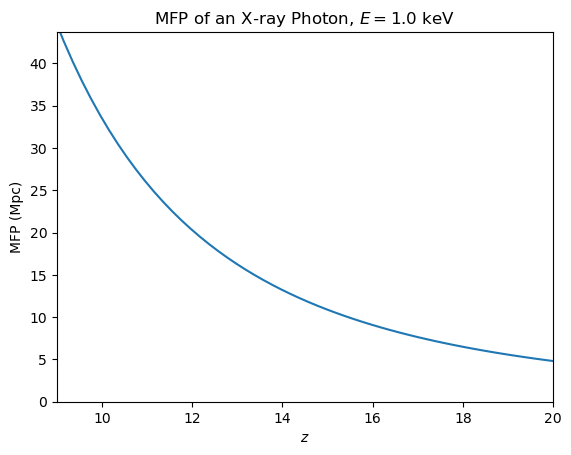

In [14]:
plt.plot(z_range, MFP_test_arr)
plt.xlabel(r'$z$')
plt.ylabel(r'MFP (Mpc)')
plt.xlim(9, 20)
plt.ylim(0, 43.7)
plt.title(r'MFP of an X-ray Photon, $E=1.0$ keV')

In [15]:
Tau_test_arr = np.zeros_like(z_range)

z_obs_test = 8

for i in range(len(z_range)):
    if z_range[i] > z_obs_test:
        Tau_test_arr[i] = Tau_X(1, z_range[i], z_obs_test, 0.0001)

Text(0.5, 1.0, 'Optical Depth of Photon with Energy $E=1$ keV')

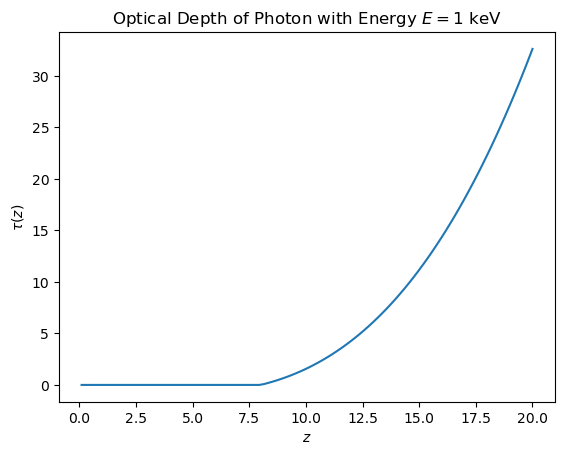

In [16]:
plt.plot(z_range, Tau_test_arr)
plt.xlabel(r'$z$')
plt.ylabel(r'$\tau(z)$')
plt.title(r'Optical Depth of Photon with Energy $E=1$ keV')

In [17]:
E_range = np.linspace(0.5, 8)

In [18]:
Tau_test_arr2 = np.zeros_like(E_range)

z_obs_test = 7

for i in range(len(E_range)):
    Tau_test_arr2[i] = Tau_X(E_range[i], 10, z_obs_test, 0.0001)

Text(0.5, 1.0, 'Optical Depth Energy Dependence')

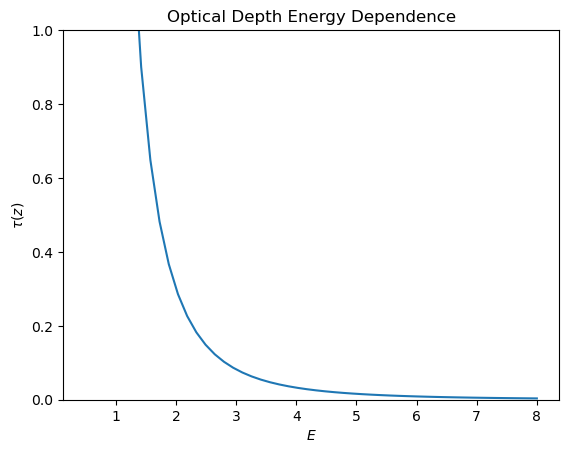

In [19]:
plt.plot(E_range, Tau_test_arr2)
plt.xlabel(r'$E$')
plt.ylabel(r'$\tau(z)$')
plt.ylim(0,1)
plt.title(r'Optical Depth Energy Dependence')

In [20]:
from utils import mean_cx_scat, Hopkin_SFRD

In [21]:
cX_vals = np.mean(mean_cx_scat) #In erg/s * yr/M
MpctoKm = 3.086 * 10 ** (19)
Yrtosec = 3.154 * 10 ** 7

def J_E_integrand(E_obs, z_obs, z_prime):

    gamma_index = 2
    E_prime = E_obs * (1 + z_prime) / (1 + z_obs)

    return Hopkin_SFRD(z_prime) * cX_vals * (1 + z_prime) ** -gamma_index / (
        (1 + z_prime) * (H(z_prime) * MpctoKm / (Yrtosec))
    ) * np.exp(-Tau_X(E_prime, z_prime, z_obs, 0.001))

#
#

def J(E, z):

    gamma_index = 2
    c_kms = 3e5

    z_start = z
    z_end = z + 4
    n_steps = 100

    dz = (z_end - z_start) / (n_steps - 1)

    normalization = (8 ** (1 - gamma_index)) / (1 - gamma_index) - (0.5 ** (1 - gamma_index)) / (1 - gamma_index)
    #

    integral = 0.0

    z_prev = z_start
    f_prev = J_E_integrand(E, z, z_prev)

    for i in range(1, n_steps):

        z_curr = z_start + i * dz
        f_curr = J_E_integrand(E, z, z_curr)

        integral += 0.5 * (f_prev + f_curr) * dz

        z_prev = z_curr
        f_prev = f_curr

    y_val = c_kms / (4 * np.pi) * (1 + z) ** 3 * (E ** (-gamma_index) / normalization) * integral / (1 + z) ** -(gamma_index)

    return y_val

In [22]:
#Test function with a constant SFRD
def J_E_integrand2(E_obs, z_obs, z_prime):

    gamma_index = 2
    E_prime = E_obs * (1 + z_prime) / (1 + z_obs)

    return 10 ** (-3) * cX_vals * (1 + z_prime) ** -gamma_index / (
        (1 + z_prime) * (H(z_prime) * MpctoKm / (Yrtosec))
    ) * np.exp(-1)

def J2(E, z):

    gamma_index = 2
    c_kms = 3e5

    z_start = z
    z_end = z + 4
    n_steps = 100

    dz = (z_end - z_start) / (n_steps - 1)

    normalization = (8 ** (1 - gamma_index)) / (1 - gamma_index) - (0.5 ** (1 - gamma_index)) / (1 - gamma_index)
    #

    integral = 0.0

    z_prev = z_start
    f_prev = J_E_integrand2(E, z, z_prev)

    for i in range(1, n_steps):

        z_curr = z_start + i * dz
        f_curr = J_E_integrand2(E, z, z_curr)

        integral += 0.5 * (f_prev + f_curr) * dz

        z_prev = z_curr
        f_prev = f_curr

    y_val = c_kms / (4 * np.pi) * (1 + z) ** 3 * (E ** (-gamma_index) / normalization) * integral / (1 + z) ** -(gamma_index)

    return y_val

#Test function with different cX_val order of magnitude
cX_vals2 = cX_vals * 10

def J_E_integrand3(E_obs, z_obs, z_prime):

    gamma_index = 2
    E_prime = E_obs * (1 + z_prime) / (1 + z_obs)

    return 10 ** (-3) * cX_vals2 * (1 + z_prime) ** -gamma_index / (
        (1 + z_prime) * (H(z_prime) * MpctoKm / (Yrtosec))
    ) * np.exp(-1)

def J3(E, z):

    gamma_index = 2
    c_kms = 3e5

    z_start = z
    z_end = z + 4
    n_steps = 100

    dz = (z_end - z_start) / (n_steps - 1)

    normalization = (8 ** (1 - gamma_index)) / (1 - gamma_index) - (0.5 ** (1 - gamma_index)) / (1 - gamma_index)
    #

    integral = 0.0

    z_prev = z_start
    f_prev = J_E_integrand3(E, z, z_prev)

    for i in range(1, n_steps):

        z_curr = z_start + i * dz
        f_curr = J_E_integrand3(E, z, z_curr)

        integral += 0.5 * (f_prev + f_curr) * dz

        z_prev = z_curr
        f_prev = f_curr

    y_val = c_kms / (4 * np.pi) * (1 + z) ** 3 * (E ** (-gamma_index) / normalization) * integral / (1 + z) ** -(gamma_index)

    return y_val

In [23]:
cX_vals = np.mean(mean_cx_scat)

cX_vals

np.float64(4.8141249842065225e+39)

In [24]:
J_test_vals2 = np.zeros_like(E_range) #J_E spectrum
J_test_vals3 = np.zeros_like(E_range)
J_test_vals4 = np.zeros_like(E_range)

for i in range(len(E_range)):
    J_test_vals2[i] = J(E_range[i], 8)
    J_test_vals3[i] = J(E_range[i], 10)
    J_test_vals4[i] = J(E_range[i], 12)

In [25]:
J_test_vals2_2 = np.zeros_like(E_range) #J_E spectrum
J_test_vals3_2 = np.zeros_like(E_range)
J_test_vals4_2 = np.zeros_like(E_range)

for i in range(len(E_range)):
    J_test_vals2_2[i] = J2(E_range[i], 8)
    J_test_vals3_2[i] = J2(E_range[i], 10)
    J_test_vals4_2[i] = J2(E_range[i], 12)

J_test_vals2_3 = np.zeros_like(E_range) #J_E spectrum
J_test_vals3_3 = np.zeros_like(E_range)
J_test_vals4_3 = np.zeros_like(E_range)

for i in range(len(E_range)):
    J_test_vals2_3[i] = J3(E_range[i], 8)
    J_test_vals3_3[i] = J3(E_range[i], 10)
    J_test_vals4_3[i] = J3(E_range[i], 12)

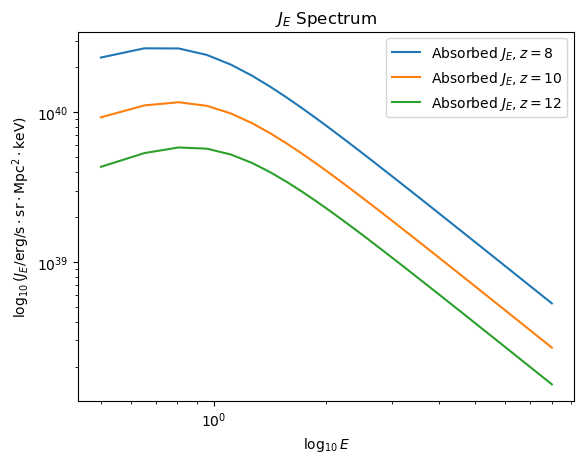

In [26]:
plt.loglog(E_range, J_test_vals2, label = r'Absorbed $J_E, z=8$')
#
plt.loglog(E_range, J_test_vals3, label = r'Absorbed $J_E, z=10$')
plt.loglog(E_range, J_test_vals4, label = r'Absorbed $J_E, z=12$')
#plt.plot(E_range, np.log10(Junab_test_vals2), label = r'Unabsorbed $J_E$')
plt.xlabel(r'$\log_{10}{E}$')
plt.ylabel(r'$\log_{10}{(J_E/\text{erg/s}\cdot\text{sr}\cdot\text{Mpc}^2\cdot\text{keV})}$')
plt.title(r'$J_E$ Spectrum')
plt.legend()

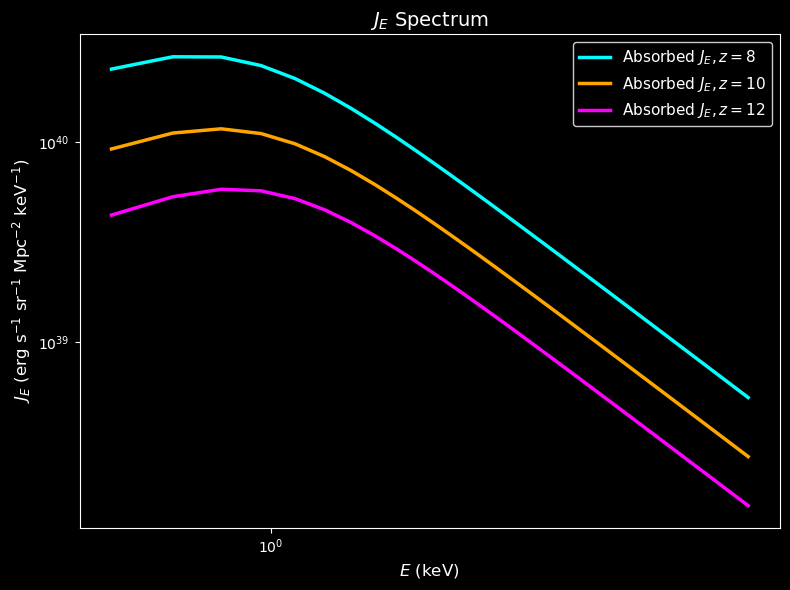

In [27]:
fig, ax = plt.subplots(figsize=(8,6))
fig.patch.set_facecolor('black')
ax.set_facecolor('black')

# --- Curves ---
ax.loglog(E_range, J_test_vals2,
          label=r'Absorbed $J_E, z=8$',
          color='#00FFFF', lw=2.5)

ax.loglog(E_range, J_test_vals3,
          label=r'Absorbed $J_E, z=10$',
          color='#FFA500', lw=2.5)

ax.loglog(E_range, J_test_vals4,
          label=r'Absorbed $J_E, z=12$',
          color='#FF00FF', lw=2.5)

# --- Labels & title ---
ax.set_xlabel(r'$E$ (keV)', fontsize=12, color='white')
ax.set_ylabel(r'$J_E$ (erg s$^{-1}$ sr$^{-1}$ Mpc$^{-2}$ keV$^{-1}$)',
              fontsize=12, color='white')
ax.set_title(r'$J_E$ Spectrum', fontsize=14, color='white')

# --- Ticks ---
ax.tick_params(colors='white')

# --- Spines ---
for spine in ax.spines.values():
    spine.set_color('white')

# --- Legend ---
legend = ax.legend(facecolor='black', edgecolor='white', fontsize=11)
for text in legend.get_texts():
    text.set_color('white')

plt.tight_layout()
plt.show()

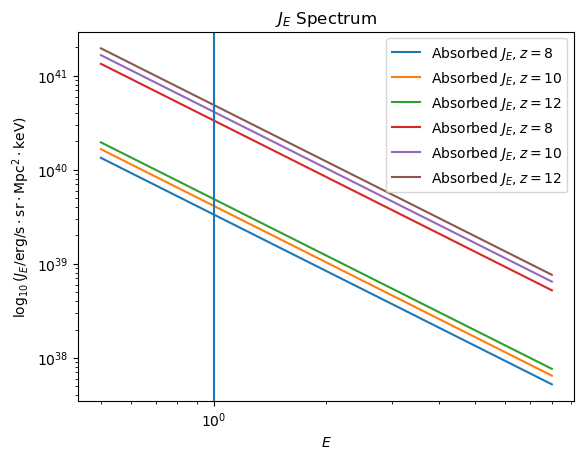

In [28]:
plt.loglog(E_range, J_test_vals2_2, label = r'Absorbed $J_E, z=8$')
#
plt.loglog(E_range, J_test_vals3_2, label = r'Absorbed $J_E, z=10$')
plt.loglog(E_range, J_test_vals4_2, label = r'Absorbed $J_E, z=12$')

plt.loglog(E_range, J_test_vals2_3, label = r'Absorbed $J_E, z=8$')
#
plt.loglog(E_range, J_test_vals3_3, label = r'Absorbed $J_E, z=10$')
plt.loglog(E_range, J_test_vals4_3, label = r'Absorbed $J_E, z=12$')
#plt.plot(E_range, np.log10(Junab_test_vals2), label = r'Unabsorbed $J_E$')
plt.xlabel(r'$E$')
plt.ylabel(r'$\log_{10}{(J_E/\text{erg/s}\cdot\text{sr}\cdot\text{Mpc}^2\cdot\text{keV})}$')
plt.title(r'$J_E$ Spectrum')
plt.legend()
plt.axvline(1)

In [29]:
J(1, 8)

np.float64(2.324053195690842e+40)

# $J_E$ Calculation for Madau Emissivity

## Metallicity-Redshift Relation

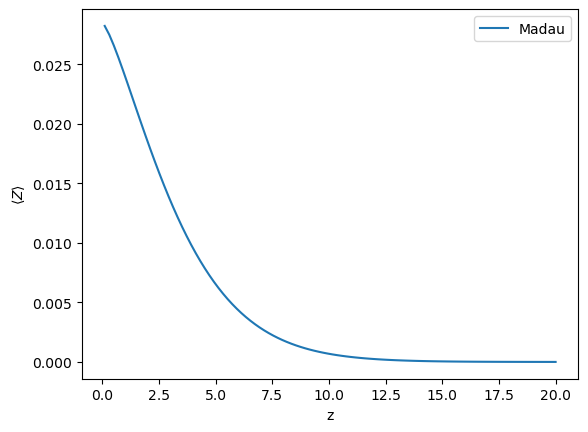

In [30]:
Z_solar = 0.02
Mean_Z = Z_solar * 10 ** (0.153 - 0.074 * z_range ** 1.34)

plt.plot(z_range, Mean_Z, label = r'Madau')
plt.xlabel(r'z')

plt.ylabel(r'$\left<Z\right>$')
plt.legend()

## Luminosity-Metallicity Relation

In [31]:
def log_cX_Mad(mean_Z):
    return 40.431737 + 135.11736 * mean_Z + -106273.6 * mean_Z ** 2 + 25606802 * mean_Z ** 3 - (3.0811049 * 10 ** 9) * mean_Z ** 4 + (2.0496541 * 10 ** (11)) * mean_Z ** 5 - (7.6798616 * 10 ** (12)) * mean_Z ** 6 + (1.5199552 * 10 ** (14)) * mean_Z ** 7 - (1.2367941 * 10 ** (15)) * mean_Z ** 8

In [32]:
log_cX_Mad_vals = np.zeros_like(Mean_Z)

for i in range(len(Mean_Z)):
    log_cX_Mad_vals[i] = log_cX_Mad(Mean_Z[i])

Text(0.5, 1.0, '$c_X$ vs $\\left<Z\\right>$ Plot (Madau Fitting Parameters)')

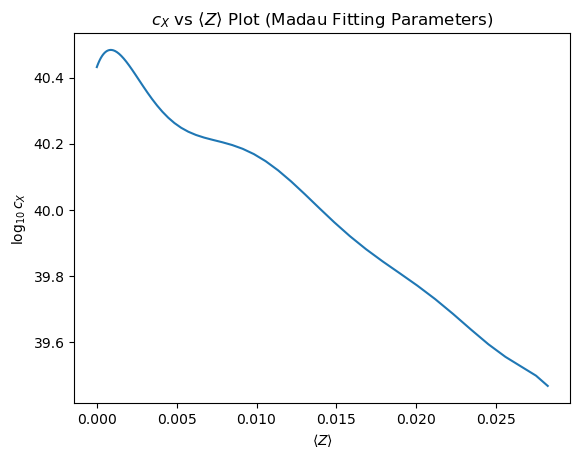

In [33]:
plt.plot(Mean_Z, log_cX_Mad_vals)
plt.xlabel(r'$\left<Z\right>$')
plt.ylabel(r'$\log_{10}c_X$')
plt.title(r'$c_X$ vs $\left<Z\right>$ Plot (Madau Fitting Parameters)')

## Luminosity-Redshift Relation

Text(0.5, 1.0, 'Luminosity vs Redshift Relation (Madau)')

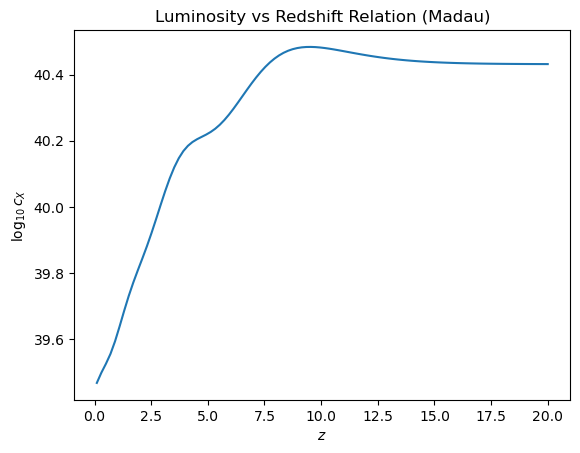

In [34]:
plt.plot(z_range, log_cX_Mad_vals)
plt.xlabel(r'$z$')
plt.ylabel(r'$\log_{10}c_X$')
plt.title(r'Luminosity vs Redshift Relation (Madau)')

## Emissivity Relations

In [35]:
def Madau_SFRD(z):
    return 0.01 * (1 + z) ** 2.6 / (1 + ((1 + z) / 3.2) ** 6.2)

Madau_fit = Madau_SFRD(z_range)

In [36]:
def Metallicity_reln(z):
    return Z_solar * 10 ** (0.153 - 0.074 * z ** 1.34)

def log_Mad_Em(z):
    Metallicity = Metallicity_reln(z)
    SFRD_val = Madau_SFRD(z)
    logcX_val = log_cX_Mad(Metallicity)
    return np.log10(SFRD_val) + logcX_val

log_Mad_Em_vals = log_Mad_Em(z_range)

Text(0, 0.5, '$\\log_{10}\\epsilon_\\text{HMXB}$')

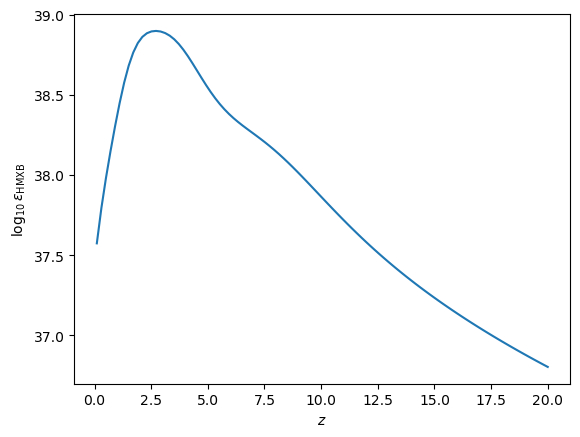

In [37]:
plt.plot(z_range, log_Mad_Em_vals)
plt.xlabel(r'$z$')
plt.ylabel(r'$\log_{10}\epsilon_\text{HMXB}$')

In [38]:
E_times_Em = np.zeros_like(E_range)

for i in range(len(E_range)):
    E_times_Em[i] = E_range[i] * 10 ** log_Mad_Em(7) * E_range[i] ** (-2)

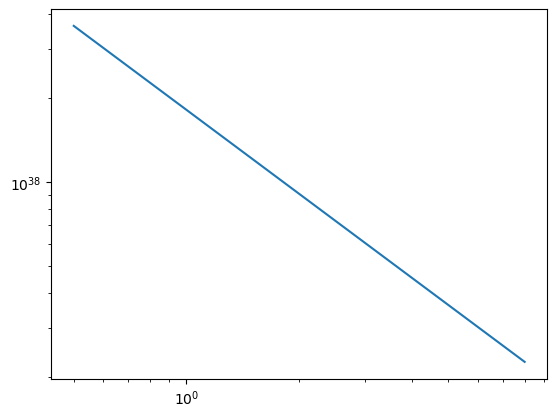

In [39]:
plt.loglog(E_range, E_times_Em)

In [40]:
def J_E_integrand_Mad(E_obs, z_obs, z_prime):

    gamma_index = 2
    E_prime = E_obs * (1 + z_prime) / (1 + z_obs)

    return 10 ** (log_Mad_Em(z_prime)) * (1 + z_prime) ** -gamma_index / (
        (1 + z_prime) * (H(z_prime) / (3.24e-20))
    ) * np.exp(-Tau_X(E_prime, z_prime, z_obs, 0.001))

def J_Mad(E, z):

    gamma_index = 2
    c_kms = 3e5 * 3.17 * 10 ** 8

    z_start = z
    z_end = z + 4
    n_steps = 100

    dz = (z_end - z_start) / (n_steps - 1)

    normalization = (8 ** (1 - gamma_index)) / (1 - gamma_index) - (0.5 ** (1 - gamma_index)) / (1 - gamma_index)

    integral = 0.0

    z_prev = z_start
    f_prev = J_E_integrand_Mad(E, z, z_prev)

    for i in range(1, n_steps):

        z_curr = z_start + i * dz
        f_curr = J_E_integrand_Mad(E, z, z_curr)

        integral += 0.5 * (f_prev + f_curr) * dz

        z_prev = z_curr
        f_prev = f_curr

    y_val = c_kms / (4 * np.pi) * (1 + z) ** 3 * (E ** (-gamma_index) / normalization) * integral / (1 + z) ** -(gamma_index)

    return y_val

In [41]:
def J2_Mad(E, z):

    gamma_index = 1.5
    c_kms = 3e5 * 3.17 * 10 ** 8

    z_start = z
    z_end = z + 4
    n_steps = 100

    dz = (z_end - z_start) / (n_steps - 1)

    normalization = (8 ** (1 - gamma_index)) / (1 - gamma_index) - (0.5 ** (1 - gamma_index)) / (1 - gamma_index)

    integral = 0.0

    z_prev = z_start
    f_prev = J_E_integrand_Mad(E, z, z_prev)

    for i in range(1, n_steps):

        z_curr = z_start + i * dz
        f_curr = J_E_integrand_Mad(E, z, z_curr)

        integral += 0.5 * (f_prev + f_curr) * dz

        z_prev = z_curr
        f_prev = f_curr

    y_val = c_kms / (4 * np.pi) * (1 + z) ** 3 * (E ** (-gamma_index) / normalization) * integral / (1 + z) ** -(gamma_index)

    return y_val

def J3_Mad(E, z):

    gamma_index = 2.5
    c_kms = 3e5 * 3.17 * 10 ** 8

    z_start = z
    z_end = z + 4
    n_steps = 100

    dz = (z_end - z_start) / (n_steps - 1)

    normalization = (8 ** (1 - gamma_index)) / (1 - gamma_index) - (0.5 ** (1 - gamma_index)) / (1 - gamma_index)

    integral = 0.0

    z_prev = z_start
    f_prev = J_E_integrand_Mad(E, z, z_prev)

    for i in range(1, n_steps):

        z_curr = z_start + i * dz
        f_curr = J_E_integrand_Mad(E, z, z_curr)

        integral += 0.5 * (f_prev + f_curr) * dz

        z_prev = z_curr
        f_prev = f_curr

    y_val = c_kms / (4 * np.pi) * (1 + z) ** 3 * (E ** (-gamma_index) / normalization) * integral / (1 + z) ** -(gamma_index)

    return y_val

In [42]:
J_test_valsMad = np.zeros_like(E_range) #J_E spectrum
J_test_valsMad2 = np.zeros_like(E_range)
J_test_valsMad3 = np.zeros_like(E_range)

for i in range(len(E_range)):
    J_test_valsMad[i] = J(E_range[i], 8)
    J_test_valsMad2[i] = J2(E_range[i], 8)
    J_test_valsMad3[i] = J3(E_range[i], 8)

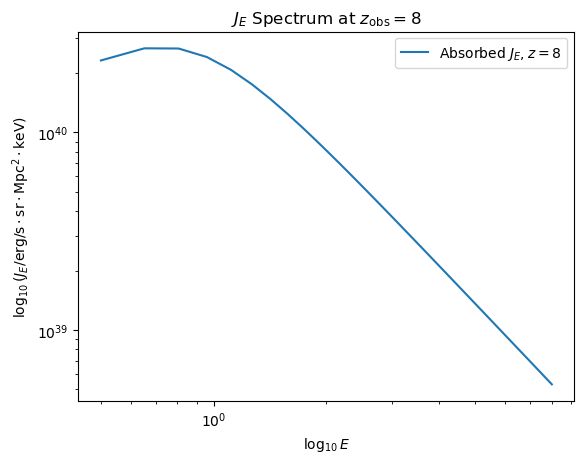

In [43]:
plt.loglog(E_range, (J_test_valsMad), label = r'Absorbed $J_E,z=8$')
#plt.loglog(E_range, (J_test_valsMad2), label = r'Absorbed $J_E,z=10$')
#plt.loglog(E_range, (J_test_valsMad3), label = r'Absorbed $J_E,z=12$')
plt.xlabel(r'$\log_{10}E$')
plt.ylabel(r'$\log_{10}{(J_E/\text{erg/s}\cdot\text{sr}\cdot\text{Mpc}^2\cdot\text{keV})}$')
plt.title(r'$J_E$ Spectrum at $z_{\text{obs}}=8$')
plt.legend()

#* 6.242 * 10 ** 8 / (3.086 * 10 ** 24) ** 2)

# Solving the Temeperature Differential Equation

## Photo-Heating Rates (Only HI)

Since this is just HI, we assume a simple $\sigma\propto E^{-3}$ relation here.

In [44]:
from scipy.integrate import quad, solve_ivp
from scipy.interpolate import interp1d

In [45]:
SIGMA_HI_0 = 6.3e-18  # cm^2
I_HI_KEV = 0.0136 #keV
I_HeI_KEV = 0.0246 #keV

def sigma_HI(E): # E in keV
    return SIGMA_HI_0 * (I_HI_KEV / E) ** 3

def H_HI(z): #Obs redshift
    def integrand(E_val, z_val):
        return (J(E_val, z_val) / (3.086 * 10 ** 24) ** 2) / E_val * (E_val - I_HI_KEV) * sigma_HI(E_val)
    E_grid = np.geomspace(0.5, 8, 100)

    integrand_vals = np.zeros_like(E_grid)
    
    for i in range(len(E_grid)):
        integrand_vals[i] = integrand(E_grid[i], z)

    return 4 * np.pi * np.trapezoid(integrand_vals, E_grid)

In [46]:
def H_HI2(z): #Obs redshift
    def integrand(E_val, z_val):
        return (J2(E_val, z_val) / (3.086 * 10 ** 24) ** 2) / E_val * (E_val - I_HI_KEV) * sigma_HI(E_val)
    E_grid = np.geomspace(0.5, 8, 100)

    integrand_vals = np.zeros_like(E_grid)
    
    for i in range(len(E_grid)):
        integrand_vals[i] = integrand(E_grid[i], z)

    return 4 * np.pi * np.trapezoid(integrand_vals, E_grid)

def H_HI3(z): #Obs redshift
    def integrand(E_val, z_val):
        return (J3(E_val, z_val) / (3.086 * 10 ** 24) ** 2) / E_val * (E_val - I_HI_KEV) * sigma_HI(E_val)
    E_grid = np.geomspace(0.5, 8, 100)

    integrand_vals = np.zeros_like(E_grid)
    
    for i in range(len(E_grid)):
        integrand_vals[i] = integrand(E_grid[i], z)

    return 4 * np.pi * np.trapezoid(integrand_vals, E_grid)

In [47]:
z_grid = np.linspace(0, 15, 100)
H_HI_vals = np.zeros_like(z_grid)

#for i in range(len(z_grid)):
#    H_HI_vals[i] = H_HI(z_grid[i])

In [48]:
#H_HI_vals2 = np.zeros_like(z_grid)

#for i in range(len(z_grid)):
#    H_HI_vals2[i] = H_HI2(z_grid[i])

In [49]:
#H_HI_vals3 = np.zeros_like(z_grid)

#for i in range(len(z_grid)):
#    H_HI_vals3[i] = H_HI3(z_grid[i])

In [50]:
#H_HI_vals_Data = np.column_stack((H_HI_vals, H_HI_vals2, H_HI_vals3))

#np.savetxt("../Data/H_HI_ValsData.csv", H_HI_vals_Data, delimiter = ",", header = "H_HI_1, H_HI_2, H_HI3")

In [51]:
H_HI_vals, H_HI_vals2, H_HI_vals3 = np.genfromtxt("../Data/H_HI_ValsData.csv", unpack = True, delimiter = ",", skip_header = 1)

Text(0.5, 1.0, 'Photoheating rate of HI as a function of $z$')

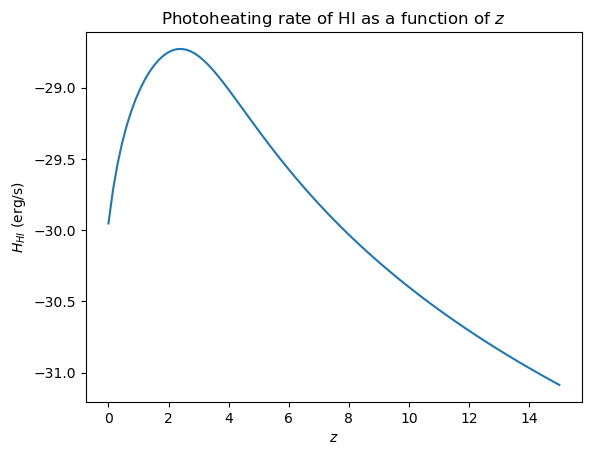

In [52]:
plt.plot(z_grid, np.log10(H_HI_vals))
#plt.plot(z_grid, np.log10(H_HI_vals2))
#plt.plot(z_grid, np.log10(H_HI_vals3))
plt.ylabel(r'$H_{HI}$ (erg/s)')
plt.xlabel(r'$z$')
plt.title(r'Photoheating rate of HI as a function of $z$')
#plt.axvline(8)

## Temperature Differential Equation (Only HI)

Since this is just HI, we assume a simple $\sigma\propto E^{-3}$ relation here.

In [53]:
mu = 1.23
k_B = 1.38 * 10 ** (-16) #erg/K
X_frac = 0.75

H_0 = 67 #km/s/Mpc
MpctoKm = 3.086 * 10 ** 19

H_HI_interp = interp1d(
    z_grid[::-1],
    H_HI_vals[::-1],
    kind='linear',          # or 'cubic' if smooth
    bounds_error=False,
    fill_value="extrapolate"
)

def temp_RHS(z, T):
    T = T[0]
    HHI = H_HI_interp(z)
    return 2 * T / (1 + z) - 2 * mu / (3 * k_B) * X_frac / ((1 + z) * (H(z) / Yrtosec)) * HHI

def in_Temp(z):
    z_dec = 150
    return 2.725 * (1 + z) ** 2 / (z_dec + 1)

In [54]:
H_HI_interp2 = interp1d(
    z_grid[::-1],
    H_HI_vals2[::-1],
    kind='linear',          # or 'cubic' if smooth
    bounds_error=False,
    fill_value="extrapolate"
)

def temp_RHS2(z, T):
    T = T[0]
    HHI = H_HI_interp2(z)
    return 2 * T / (1 + z) - 2 * mu / (3 * k_B) * X_frac / ((1 + z) * (H(z) / Yrtosec)) * HHI

H_HI_interp3 = interp1d(
    z_grid[::-1],
    H_HI_vals3[::-1],
    kind='linear',          # or 'cubic' if smooth
    bounds_error=False,
    fill_value="extrapolate"
)

def temp_RHS3(z, T):
    T = T[0]
    HHI = H_HI_interp3(z)
    return 2 * T / (1 + z) - 2 * mu / (3 * k_B) * X_frac / ((1 + z) * (H(z) / Yrtosec)) * HHI

In [55]:
T_sol = solve_ivp(temp_RHS, t_span = (15, 6), y0 = [in_Temp(15)], t_eval = np.linspace(15, 6, 500))

In [56]:
T_sol2 = solve_ivp(temp_RHS2, t_span = (15, 6), y0 = [in_Temp(15)], t_eval = np.linspace(15, 6, 500))
T_sol3 = solve_ivp(temp_RHS3, t_span = (15, 6), y0 = [in_Temp(15)], t_eval = np.linspace(15, 6, 500))

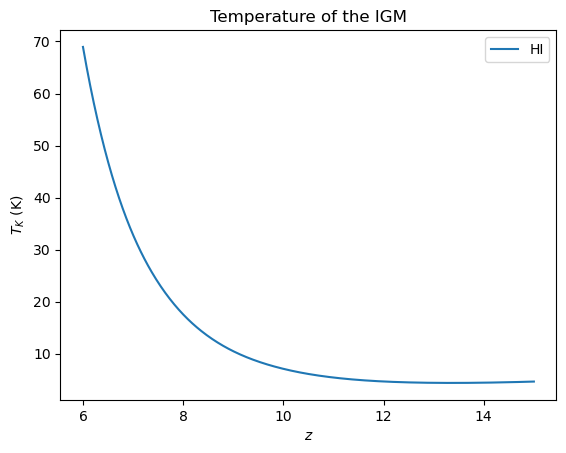

In [57]:
z_sol_grid = T_sol.t[::-1]
T_sol_vals = T_sol.y[0][::-1]

#z_sol_grid2 = T_sol2.t[::-1]
#T_sol_vals2 = T_sol2.y[0][::-1]

#z_sol_grid3 = T_sol3.t[::-1]
#T_sol_vals3 = T_sol3.y[0][::-1]

plt.plot(z_sol_grid, T_sol_vals, label = r'HI')
#plt.plot(z_sol_grid2, T_sol_vals2, label = r'Constant')
#plt.plot(z_sol_grid3, T_sol_vals3, label = r'Constant New')
plt.xlabel(r'$z$')
plt.ylabel(r'$T_K$ (K)')
plt.title(r'Temperature of the IGM')
plt.legend()

## Photo-Heating Rates (Full Neutral IGM)

Here we take the $\sigma$ fitting relations found in Verner 1996.

In [58]:
def H_HI_FullSigma(z): #Obs redshift
    def integrand(E_val, z_val):
        return (J(E_val, z_val) / (3.086 * 10 ** 24) ** 2) / E_val * (E_val - I_HI_KEV) * sigma_FullSigma(E_val, E_0_HI, y_0_HI, y_1_HI, y_w_HI, P_HI, y_a_HI, sigma_0_HI)
    E_grid = np.geomspace(0.5, 8, 100)

    integrand_vals = np.zeros_like(E_grid)
    
    for i in range(len(E_grid)):
        integrand_vals[i] = integrand(E_grid[i], z)

    return 4 * np.pi * np.trapezoid(integrand_vals, E_grid)

def H_HeI_FullSigma(z): #Obs redshift
    def integrand(E_val, z_val):
        return (J(E_val, z_val) / (3.086 * 10 ** 24) ** 2) / E_val * (E_val - I_HeI_KEV) * sigma_FullSigma(E_val, E_0_HeI, y_0_HeI, y_1_HeI, y_w_HeI, P_HeI, y_a_HeI, sigma_0_HeI)
    E_grid = np.geomspace(0.5, 8, 100)

    integrand_vals = np.zeros_like(E_grid)
    
    for i in range(len(E_grid)):
        integrand_vals[i] = integrand(E_grid[i], z)

    return 4 * np.pi * np.trapezoid(integrand_vals, E_grid)

In [59]:
H_HI_vals_FullSigma = np.zeros_like(z_grid)
H_HeI_vals_FullSigma = np.zeros_like(z_grid)

#for i in range(len(z_grid)):
#    H_HI_vals_FullSigma[i] = H_HI_FullSigma(z_grid[i])
#    H_HeI_vals_FullSigma[i] = H_HeI_FullSigma(z_grid[i])

In [60]:
#H_Neutral_vals_Data = np.column_stack((H_HI_vals_FullSigma, H_HeI_vals_FullSigma))

#np.savetxt("../Data/H_Neutral_ValsData.csv", H_Neutral_vals_Data, delimiter = ",", header = "H_HI, H_HeI")

In [61]:
H_HI_vals_FullSigma, H_HeI_vals_FullSigma = np.genfromtxt("../Data/H_Neutral_ValsData.csv", unpack = True, delimiter = ",", skip_header = 1)

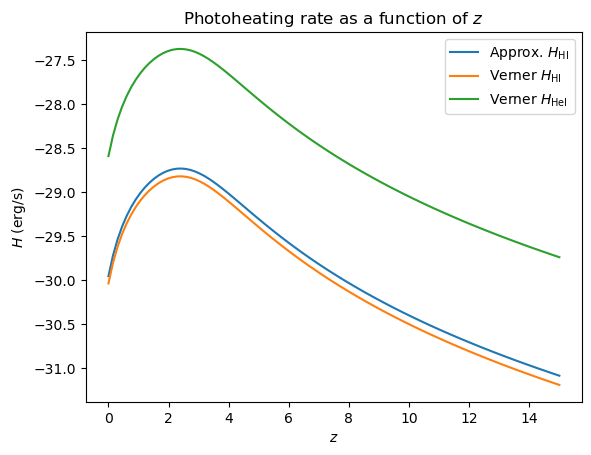

In [62]:
plt.plot(z_grid, np.log10(H_HI_vals), label = r'Approx. $H_\text{HI}$')
plt.plot(z_grid, np.log10(H_HI_vals_FullSigma), label = r'Verner $H_\text{HI}$')
plt.plot(z_grid, np.log10(H_HeI_vals_FullSigma), label = r'Verner $H_\text{HeI}$')
plt.ylabel(r'$H$ (erg/s)')
plt.xlabel(r'$z$')
plt.title(r'Photoheating rate as a function of $z$')
plt.legend()

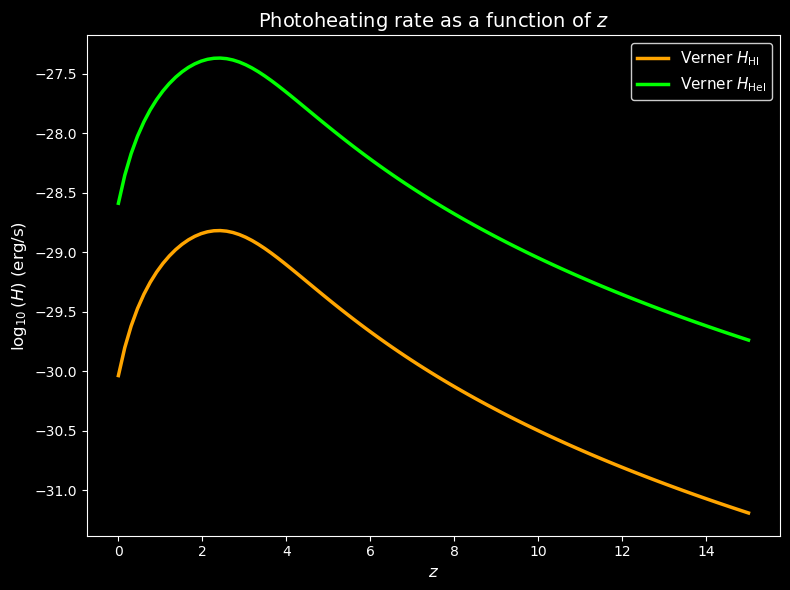

In [63]:
fig, ax = plt.subplots(figsize=(8,6))
fig.patch.set_facecolor('black')
ax.set_facecolor('black')

# --- Curves ---
#ax.plot(z_grid, np.log10(H_HI_vals),
#        label=r'Approx. $H_\text{HI}$',
#        color='#00FFFF', lw=2.5)   # cyan

ax.plot(z_grid, np.log10(H_HI_vals_FullSigma),
        label=r'Verner $H_\text{HI}$',
        color='#FFA500', lw=2.5)   # orange

ax.plot(z_grid, np.log10(H_HeI_vals_FullSigma),
        label=r'Verner $H_\text{HeI}$',
        color='#00FF00', lw=2.5)   # green

# --- Labels & title ---
ax.set_xlabel(r'$z$', fontsize=12, color='white')
ax.set_ylabel(r'$\log_{10}(H)$ (erg/s)', fontsize=12, color='white')
ax.set_title(r'Photoheating rate as a function of $z$', fontsize=14, color='white')

# --- Ticks ---
ax.tick_params(colors='white')

# --- Spines ---
for spine in ax.spines.values():
    spine.set_color('white')

# --- Legend ---
legend = ax.legend(facecolor='black', edgecolor='white', fontsize=11)
for text in legend.get_texts():
    text.set_color('white')

plt.tight_layout()
plt.show()

## Temperature Differential Equation (Full Neutral IGM)

Here we take the $\sigma$ fitting relations found in Verner 1996.

In [64]:
Y_frac = 0.25
He_n_factor = Y_frac / 4

H_HI_interp_FullSigma = interp1d(
    z_grid[::-1],
    H_HI_vals_FullSigma[::-1],
    kind='linear',          # or 'cubic' if smooth
    bounds_error=False,
    fill_value="extrapolate"
)

H_HeI_interp_FullSigma = interp1d(
    z_grid[::-1],
    H_HeI_vals_FullSigma[::-1],
    kind='linear',          # or 'cubic' if smooth
    bounds_error=False,
    fill_value="extrapolate"
)

def temp_RHS_FullSigma(z, T):
    T = T[0]
    HHI = H_HI_interp_FullSigma(z)
    HHeI = H_HeI_interp_FullSigma(z)
    return 2 * T / (1 + z) - 2 * mu / (3 * k_B) * (X_frac * HHI + He_n_factor * HHeI) / ((1 + z) * (H(z) / Yrtosec))

In [65]:
T_sol_FullSigma = solve_ivp(temp_RHS_FullSigma, t_span = (15, 6), y0 = [in_Temp(15)], t_eval = np.linspace(15, 6, 500))

In [66]:
def adiabatic_temperature(z_array, T_init):
    z0 = z_array[0]
    return T_init * ((1 + z_array) / (1 + z0))**2

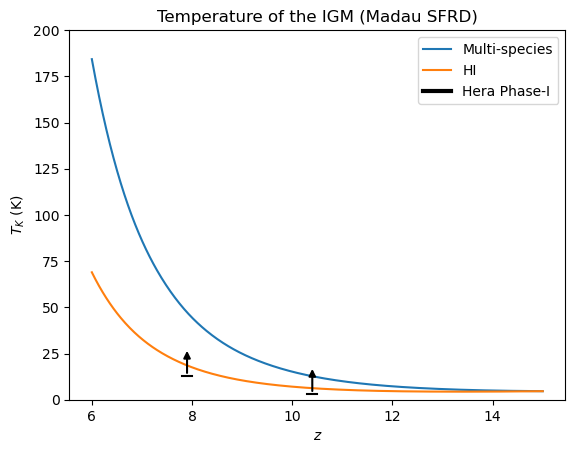

In [67]:
z_sol_grid_FullSigma = T_sol_FullSigma.t[::-1]
T_sol_vals_FullSigma = T_sol_FullSigma.y[0][::-1]

plt.plot(z_sol_grid_FullSigma, T_sol_vals_FullSigma, label = r'Multi-species')
plt.plot(z_sol_grid, T_sol_vals, label = r'HI')
plt.xlabel(r'$z$')
plt.ylabel(r'$T_K$ (K)')
plt.title(r'Temperature of the IGM (Madau SFRD)')
plt.legend()

# --- Literature constraints ---

# Redshifts
z1 = 10.4
z2 = 7.9

# Temperature limits (from paper)
T1_min, T1_max = 3.2, 313.2      # at z = 10.4
T2_min, T2_max = 13, 4768        # at z = 7.9

# --- Vertical lines at the redshifts ---
#plt.axvline(z1, color='black', linestyle='--', alpha=0.7)
#plt.axvline(z2, color='black', linestyle='--', alpha=0.7)

# --- Plot vertical segments showing allowed temperature ranges ---
plt.plot(z1, T1_min, color='black', linewidth=3, label='Hera Phase-I')
plt.plot(z2, T2_min, color='black', linewidth=3)

# --- Optional: caps to make it look cleaner (like error bars) ---
plt.plot([z1-0.1, z1+0.1], [T1_min, T1_min], color='black')
plt.plot([z1-0.1, z1+0.1], [T1_max, T1_max], color='black')

plt.plot([z2-0.1, z2+0.1], [T2_min, T2_min], color='black')
plt.plot([z2-0.1, z2+0.1], [T2_max, T2_max], color='black')

offset = 15

plt.annotate(
    '', 
    xy=(z1, T1_min + offset),   # arrow head (above)
    xytext=(z1, T1_min),        # start at point
    arrowprops=dict(arrowstyle='-|>', color='black', lw=1.5)
)

plt.annotate(
    '', 
    xy=(z2, T2_min + offset),
    xytext=(z2, T2_min),
    arrowprops=dict(arrowstyle='-|>', color='black', lw=1.5)
)
plt.ylim(0, 200)
plt.legend()

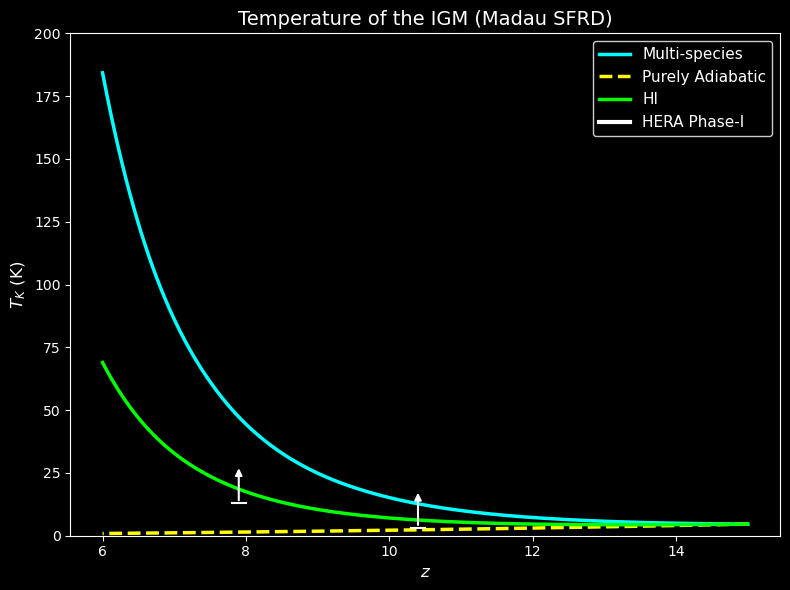

In [68]:
# Extract data
z_sol_grid_FullSigma = T_sol_FullSigma.t[::-1]
T_sol_vals_FullSigma = T_sol_FullSigma.y[0][::-1]

adiabatic_temp_vals = adiabatic_temperature(z_sol_grid_FullSigma[::-1], in_Temp(15))

fig, ax = plt.subplots(figsize=(8,6))
fig.patch.set_facecolor('black')
ax.set_facecolor('black')

# --- Curves ---
ax.plot(z_sol_grid_FullSigma, T_sol_vals_FullSigma,
        label=r'Multi-species', color='#00FFFF', lw=2.5)

ax.plot(z_sol_grid_FullSigma[::-1], adiabatic_temp_vals,
        label=r'Purely Adiabatic', color='#FFFF00', lw=2.5, ls='--')

ax.plot(z_sol_grid, T_sol_vals,
        label=r'HI', color='#00FF00', lw=2.5)

# --- Labels & title ---
ax.set_xlabel(r'$z$', fontsize=12, color='white')
ax.set_ylabel(r'$T_K$ (K)', fontsize=12, color='white')
ax.set_title(r'Temperature of the IGM (Madau SFRD)', fontsize=14, color='white')

# --- Ticks ---
ax.tick_params(colors='white')

# --- Spines ---
for spine in ax.spines.values():
    spine.set_color('white')

# --- Literature constraints ---
z1 = 10.4
z2 = 7.9

T1_min, T1_max = 3.2, 313.2
T2_min, T2_max = 13, 4768

constraint_color = 'white'

# Points
ax.plot(z1, T1_min, color=constraint_color, linewidth=3, label='HERA Phase-I')
ax.plot(z2, T2_min, color=constraint_color, linewidth=3)

# Caps
ax.plot([z1-0.1, z1+0.1], [T1_min, T1_min], color=constraint_color)
ax.plot([z1-0.1, z1+0.1], [T1_max, T1_max], color=constraint_color)

ax.plot([z2-0.1, z2+0.1], [T2_min, T2_min], color=constraint_color)
ax.plot([z2-0.1, z2+0.1], [T2_max, T2_max], color=constraint_color)

# Arrows
offset = 15

ax.annotate(
    '',
    xy=(z1, T1_min + offset),
    xytext=(z1, T1_min),
    arrowprops=dict(arrowstyle='-|>', color=constraint_color, lw=1.5)
)

ax.annotate(
    '',
    xy=(z2, T2_min + offset),
    xytext=(z2, T2_min),
    arrowprops=dict(arrowstyle='-|>', color=constraint_color, lw=1.5)
)

# --- Limits ---
ax.set_ylim(0, 200)

# --- Legend ---
legend = ax.legend(facecolor='black', edgecolor='white', fontsize=11)
for text in legend.get_texts():
    text.set_color('white')

plt.tight_layout()
plt.show()

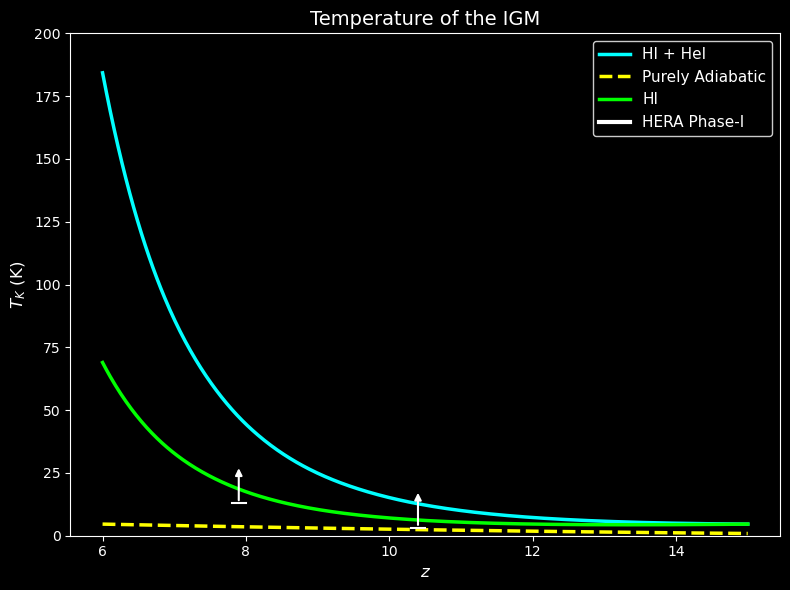

In [69]:
# Extract data
z_sol_grid_FullSigma = T_sol_FullSigma.t[::-1]
T_sol_vals_FullSigma = T_sol_FullSigma.y[0][::-1]

# Create figure
fig, ax = plt.subplots(figsize=(8,6))
fig.patch.set_facecolor('black')
ax.set_facecolor('black')

# --- Main curves ---
ax.plot(z_sol_grid_FullSigma, T_sol_vals_FullSigma,
        label=r'HI + HeI', color='#00FFFF', lw=2.5)

ax.plot(z_sol_grid_FullSigma, adiabatic_temp_vals,
        label=r'Purely Adiabatic', color='#FFFF00', lw=2.5, ls='--')

ax.plot(z_sol_grid, T_sol_vals,
        label=r'HI', color='#00FF00', lw=2.5)

# --- Labels & title ---
ax.set_xlabel(r'$z$', fontsize=12, color='white')
ax.set_ylabel(r'$T_K$ (K)', fontsize=12, color='white')
ax.set_title(r'Temperature of the IGM', fontsize=14, color='white')

# --- Ticks ---
ax.tick_params(colors='white')

# --- Spines ---
for spine in ax.spines.values():
    spine.set_color('white')

# --- Literature constraints ---
z1 = 10.4
z2 = 7.9

T1_min, T1_max = 3.2, 313.2
T2_min, T2_max = 13, 4768

# Use WHITE instead of black so it's visible
constraint_color = 'white'

# Vertical constraint points
ax.plot(z1, T1_min, color=constraint_color, linewidth=3, label='HERA Phase-I')
ax.plot(z2, T2_min, color=constraint_color, linewidth=3)

# Caps
ax.plot([z1-0.1, z1+0.1], [T1_min, T1_min], color=constraint_color)
ax.plot([z1-0.1, z1+0.1], [T1_max, T1_max], color=constraint_color)

ax.plot([z2-0.1, z2+0.1], [T2_min, T2_min], color=constraint_color)
ax.plot([z2-0.1, z2+0.1], [T2_max, T2_max], color=constraint_color)

# Arrows
offset = 15

ax.annotate(
    '',
    xy=(z1, T1_min + offset),
    xytext=(z1, T1_min),
    arrowprops=dict(arrowstyle='-|>', color=constraint_color, lw=1.5)
)

ax.annotate(
    '',
    xy=(z2, T2_min + offset),
    xytext=(z2, T2_min),
    arrowprops=dict(arrowstyle='-|>', color=constraint_color, lw=1.5)
)

# --- Limits ---
ax.set_ylim(0, 200)

# --- Legend ---
legend = ax.legend(facecolor='black', edgecolor='white', fontsize=11)
for text in legend.get_texts():
    text.set_color('white')

plt.tight_layout()
plt.show()

# Reionized IGM Calculations

## Full $\lambda_\text{X}$ (Valid for All Energies)

### Fitting Function for Cosmological Reionization

In [70]:
from utils import Mad_data

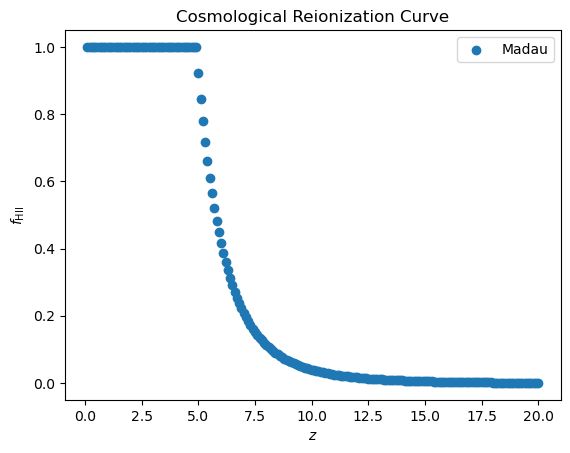

In [71]:
plt.scatter(Mad_data[0], Mad_data[1], label = r'Madau')
plt.xlabel(r'$z$')
plt.ylabel(r'$f_\text{HII}$')
plt.title(r'Cosmological Reionization Curve')
plt.legend()

In [72]:
mask = Mad_data[1] >= 1

if np.any(mask):
    idx = np.argmax(mask)
else:
    idx = len(Mad_data[1]) - 1

In [73]:
f_reion_new = Mad_data[1][:idx+1]
z_reion_new = Mad_data[0][:idx+1]

In [74]:
from scipy.optimize import curve_fit

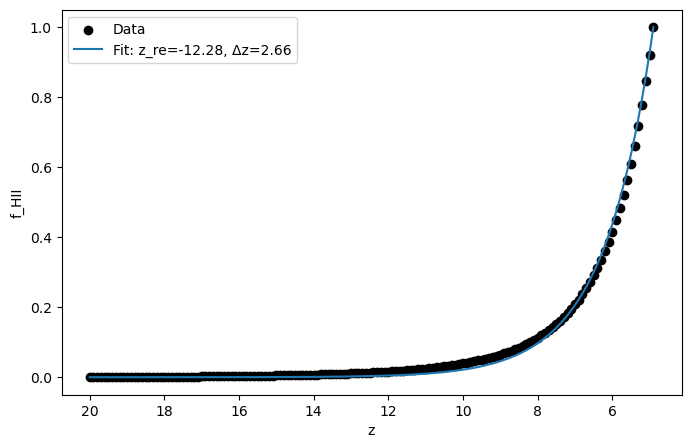

In [75]:
z = z_reion_new
f = f_reion_new

z0, zN = z[0], z[-1]

# tanh model with endpoint normalization
def tanh_model(z, z_re, delta_z):
    t = np.tanh((z - z_re) / delta_z)
    
    t0 = np.tanh((z0 - z_re) / delta_z)
    t1 = np.tanh((zN - z_re) / delta_z)
    
    return (t - t0) / (t1 - t0)

# initial guesses
z_re_guess = z[np.argmin(np.abs(f - 0.5))]
delta_z_guess = 1.0

p0 = [z_re_guess, delta_z_guess]

# fit
params, _ = curve_fit(tanh_model, z, f, p0=p0)

z_re_fit, delta_z_fit = params

# fitted curve
f_fit = tanh_model(z, z_re_fit, delta_z_fit)

# plot
plt.figure(figsize=(8,5))
plt.scatter(z, f, color='black', label='Data')
plt.plot(z, f_fit, label=f'Fit: z_re={z_re_fit:.2f}, Δz={delta_z_fit:.2f}')

plt.xlabel('z')
plt.ylabel('f_HII')
plt.legend()
plt.gca().invert_xaxis()
plt.show()

In [76]:
# store endpoints once
z0 = z_reion_new[0]   # highest z (fraction ~ 0)
zN = z_reion_new[-1]  # lowest z (fraction ~ 1)

def f_reion_model(z_input):
    z_input = np.asarray(z_input)  # handle scalars + arrays
    
    # compute tanh fit
    t = np.tanh((z_input - z_re_fit) / delta_z_fit)
    t0 = np.tanh((z0 - z_re_fit) / delta_z_fit)
    t1 = np.tanh((zN - z_re_fit) / delta_z_fit)
    
    f_fit = (t - t0) / (t1 - t0)
    
    # apply physical bounds
    f_out = np.where(
        z_input > z0, 0.0,            # higher z → neutral
        np.where(
            z_input < zN, 1.0,        # lower z → fully ionized
            f_fit                     # inside domain → fit
        )
    )
    
    return f_out

In [77]:
test_f_arr = np.zeros_like(z_range)

for i in range(len(z_range)):
    test_f_arr[i] = f_reion_model(z_range[i])

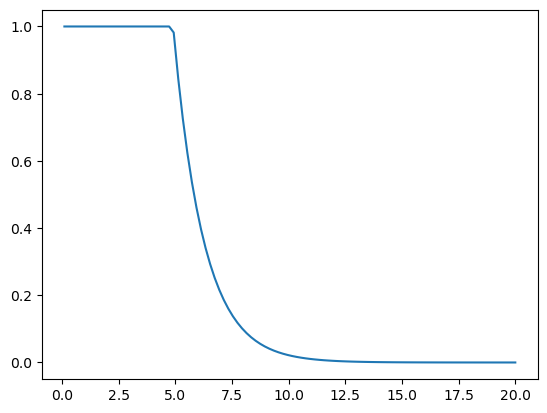

In [78]:
plt.plot(z_range, test_f_arr)

In [79]:
def Lambda_X_FullSigma(E, z):
    m_p_SM = m_p * 5.03 * 10 ** (-34)
    n_H0 = Om_b * rho_c / m_p_SM
    y = 0.083
    eff_sigma_Mpc = ((1 - f_reion_model(z)) * sigma_FullSigma(E, E_0_HI, y_0_HI, y_1_HI, y_w_HI, P_HI, y_a_HI, sigma_0_HI) + y * (1 - f_reion_model(z)) * sigma_FullSigma(E, E_0_HeI, y_0_HeI, y_1_HeI, y_w_HeI, P_HeI, y_a_HeI, sigma_0_HeI) + y * f_reion_model(z) * sigma_FullSigma(E, E_0_HeII, y_0_HeII, y_1_HeII, y_w_HeII, P_HeII, y_a_HeII, sigma_0_HeII)) * (3.24 * 10 ** (-25)) ** 2
    X = 0.75
    return (1 + z) ** (-3) / (X * n_H0 * eff_sigma_Mpc)

In [80]:
Lambda_FullSigma_Vals = np.zeros_like(z_range)

for i in range(len(z_range)):
    Lambda_FullSigma_Vals[i] = Lambda_X_FullSigma(1, Mad_data[0][i])

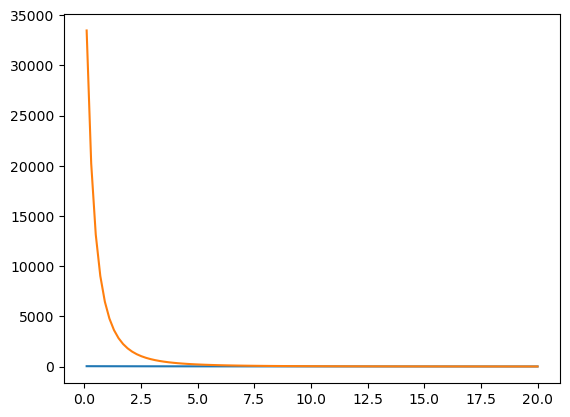

In [81]:
plt.plot(z_range, Lambda_FullSigma_Vals[::-1])
plt.plot(z_range, MFP_test_arr)

In [82]:
Lambda_FullSigma_valsE = np.zeros_like(E_range)
Lambda_neutralSigma_valsE = np.zeros_like(E_range)

for i in range(len(E_range)):
    Lambda_FullSigma_valsE[i] = Lambda_X_FullSigma(E_range[i], Mad_data[0][120])
    Lambda_neutralSigma_valsE[i] = MFP_X(E_range[i], Mad_data[0][120])

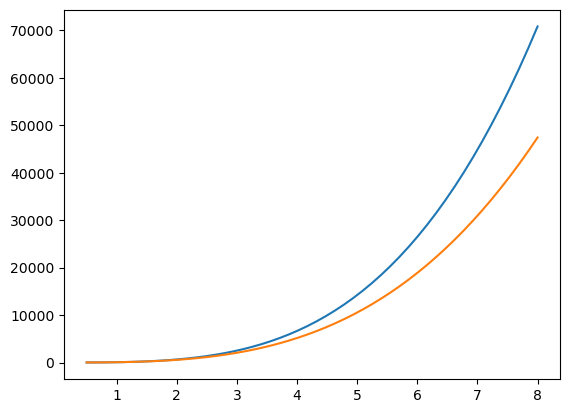

In [83]:
plt.plot(E_range, Lambda_FullSigma_valsE)
plt.plot(E_range, Lambda_neutralSigma_valsE)

Text(0.5, 0, '$E$ (keV)')

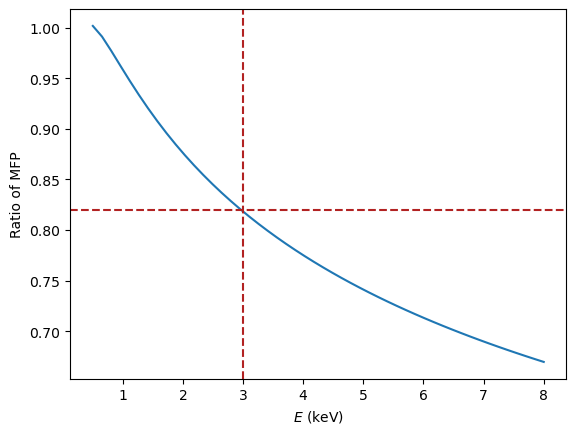

In [84]:
Lambda_vals_ratio = Lambda_neutralSigma_valsE / Lambda_FullSigma_valsE

plt.plot(E_range, Lambda_vals_ratio)
plt.axhline(0.82, ls = '--', color = r'firebrick')
plt.axvline(3, ls = '--', color = r'firebrick')
plt.ylabel(r'Ratio of MFP')
plt.xlabel(r'$E$ (keV)')

In [85]:
def Tau_X_integrand_FullSigma(E_prime, z_b, z_p): #Dummy variable of integration
    c_val = (3 * 10 ** 5) * 3.154 * 10 ** 7 #speed of light in km/yr
    E = E_prime * (1 + z_b) / (1 + z_p)
    return c_val / ((1 + z_b) * (H(z_b) * 3.086 * 10 ** (19)) * Lambda_X_FullSigma(E, z_b)) #H(z) in km/yr*Mpc

@jit(nopython=True)
def Tau_X_FullSigma(E_p, z_p, z, delta_z): #X-ray Optical Depth, proper coordinates at some emission redshift z_p and energy E_p, observed at z
    c_val = (3 * 10 ** 5) * 3.154 * 10 ** 7 #speed of light in km/yr
    integration_steps = int((z_p - z) / delta_z)
    z_arr = np.linspace(z, z_p, integration_steps)
    integrand_vals = np.zeros_like(z_arr)
    for i in range(len(z_arr)):
        integrand_vals[i] = Tau_X_integrand(E_p, z_arr[i], z_p)
    return np.trapz(integrand_vals, z_arr)

In [86]:
tau_FullSigma_vals = np.zeros_like(z_range)

z_obs_test = 8

for i in range(len(z_range)):
    if z_range[i] > z_obs_test:
        tau_FullSigma_vals[i] = Tau_X_FullSigma(1, z_range[i], z_obs_test, 0.0001)

Text(0.5, 1.0, 'Optical Depth')

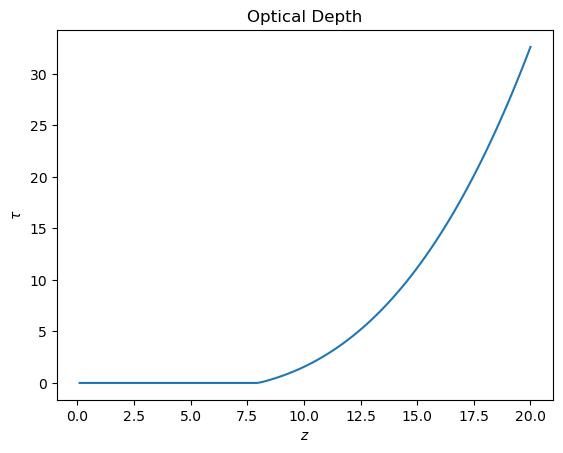

In [87]:
plt.plot(z_range, tau_FullSigma_vals)
plt.xlabel(r'$z$')
plt.ylabel(r'$\tau$')
plt.title(r'Optical Depth')

In [88]:
cX_vals = np.mean(mean_cx_scat) #In erg/s * yr/M
MpctoKm = 3.086 * 10 ** (19)
Yrtosec = 3.154 * 10 ** 7

def J_E_integrand_FullSigma_reion(E_obs, z_obs, z_prime):

    gamma_index = 2
    E_prime = E_obs * (1 + z_prime) / (1 + z_obs)

    return Hopkin_SFRD(z_prime) * cX_vals * (1 + z_prime) ** -gamma_index / (
        (1 + z_prime) * (H(z_prime) * MpctoKm / (Yrtosec))
    ) * np.exp(-Tau_X_FullSigma(E_prime, z_prime, z_obs, 0.001))

#
#

def J_FullSigma_reion(E, z):

    gamma_index = 2
    c_kms = 3e5

    z_start = z
    z_end = z + 4
    n_steps = 100

    dz = (z_end - z_start) / (n_steps - 1)

    normalization = (8 ** (1 - gamma_index)) / (1 - gamma_index) - (0.5 ** (1 - gamma_index)) / (1 - gamma_index)
    #

    integral = 0.0

    z_prev = z_start
    f_prev = J_E_integrand_FullSigma_reion(E, z, z_prev)

    for i in range(1, n_steps):

        z_curr = z_start + i * dz
        f_curr = J_E_integrand_FullSigma_reion(E, z, z_curr)

        integral += 0.5 * (f_prev + f_curr) * dz

        z_prev = z_curr
        f_prev = f_curr

    y_val = c_kms / (4 * np.pi) * (1 + z) ** 3 * (E ** (-gamma_index) / normalization) * integral / (1 + z) ** -(gamma_index)

    return y_val

In [89]:
J_test_vals2_FullSigma_reion = np.zeros_like(E_range) #J_E spectrum
J_test_vals3_FullSigma_reion = np.zeros_like(E_range)
J_test_vals4_FullSigma_reion = np.zeros_like(E_range)

for i in range(len(E_range)):
    J_test_vals2_FullSigma_reion[i] = J_FullSigma_reion(E_range[i], 8)
    J_test_vals3_FullSigma_reion[i] = J_FullSigma_reion(E_range[i], 10)
    J_test_vals4_FullSigma_reion[i] = J_FullSigma_reion(E_range[i], 12)

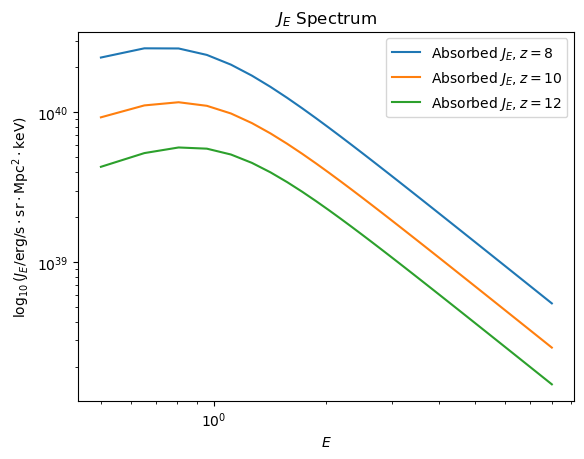

In [90]:
plt.loglog(E_range, J_test_vals2_FullSigma_reion, label = r'Absorbed $J_E, z=8$')
#
plt.loglog(E_range, J_test_vals3_FullSigma_reion, label = r'Absorbed $J_E, z=10$')
plt.loglog(E_range, J_test_vals4_FullSigma_reion, label = r'Absorbed $J_E, z=12$')
plt.xlabel(r'$E$')
plt.ylabel(r'$\log_{10}{(J_E/\text{erg/s}\cdot\text{sr}\cdot\text{Mpc}^2\cdot\text{keV})}$')
plt.title(r'$J_E$ Spectrum')
plt.legend()

## Photo-Heating Rates (Full Neutral IGM)

In [91]:
def H_HI_FullSigma_reion(z): #Obs redshift
    def integrand(E_val, z_val):
        return (J_FullSigma(E_val, z_val) / (3.086 * 10 ** 24) ** 2) / E_val * (E_val - I_HI_KEV) * sigma_FullSigma(E_val, E_0_HI, y_0_HI, y_1_HI, y_w_HI, P_HI, y_a_HI, sigma_0_HI)
    E_grid = np.geomspace(0.5, 8, 100)

    integrand_vals = np.zeros_like(E_grid)
    
    for i in range(len(E_grid)):
        integrand_vals[i] = integrand(E_grid[i], z)

    return 4 * np.pi * np.trapezoid(integrand_vals, E_grid)

def H_HeI_FullSigma_reion(z): #Obs redshift
    def integrand(E_val, z_val):
        return (J_FullSigma(E_val, z_val) / (3.086 * 10 ** 24) ** 2) / E_val * (E_val - I_HeI_KEV) * sigma_FullSigma(E_val, E_0_HeI, y_0_HeI, y_1_HeI, y_w_HeI, P_HeI, y_a_HeI, sigma_0_HeI)
    E_grid = np.geomspace(0.5, 8, 100)

    integrand_vals = np.zeros_like(E_grid)
    
    for i in range(len(E_grid)):
        integrand_vals[i] = integrand(E_grid[i], z)

    return 4 * np.pi * np.trapezoid(integrand_vals, E_grid)

def H_HeII_FullSigma_reion(z): #Obs redshift
    def integrand(E_val, z_val):
        return (J_FullSigma(E_val, z_val) / (3.086 * 10 ** 24) ** 2) / E_val * (E_val - I_HeI_KEV) * sigma_FullSigma(E_val, E_0_HeII, y_0_HeII, y_1_HeII, y_w_HeII, P_HeII, y_a_HeII, sigma_0_HeII)
    E_grid = np.geomspace(0.5, 8, 100)

    integrand_vals = np.zeros_like(E_grid)
    
    for i in range(len(E_grid)):
        integrand_vals[i] = integrand(E_grid[i], z)

    return 4 * np.pi * np.trapezoid(integrand_vals, E_grid)

In [92]:
#H_HI_vals_FullSigma_reion = np.zeros_like(z_grid)
#H_HeI_vals_FullSigma_reion = np.zeros_like(z_grid)
#H_HeII_vals_FullSigma_reion = np.zeros_like(z_grid)

#for i in range(len(z_grid)):
#    H_HI_vals_FullSigma_reion[i] = H_HI_FullSigma_reion(z_grid[i])
#    H_HeI_vals_FullSigma_reion[i] = H_HeI_FullSigma_reion(z_grid[i])
#    H_HeII_vals_FullSigma_reion[i] = H_HeII_FullSigma_reion(z_grid[i])

In [93]:
#H_reion_vals_Data = np.column_stack((H_HI_vals_FullSigma_reion, H_HeI_vals_FullSigma_reion, H_HeII_vals_FullSigma_reion))

#np.savetxt("../Data/H_reion_ValsData.csv", H_reion_vals_Data, delimiter = ",", header = "H_HI, H_HeI, H_HeII")

In [94]:
H_HI_vals_FullSigma_reion, H_HeI_vals_FullSigma_reion, H_HeII_vals_FullSigma_reion = np.genfromtxt("../Data/H_reion_ValsData.csv", unpack = True, delimiter = ",", skip_header = 1)

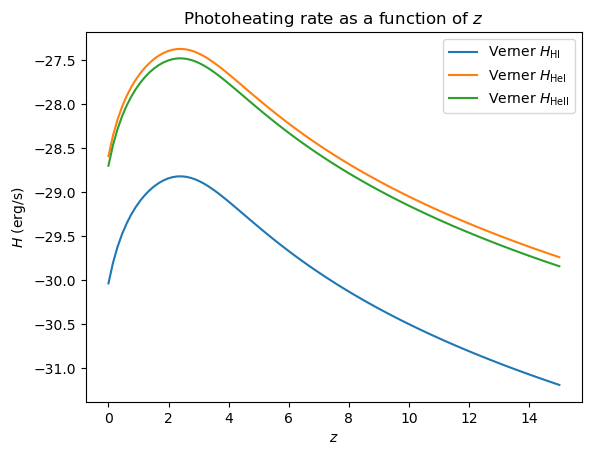

In [95]:
#plt.plot(z_grid, np.log10(H_HI_vals), label = r'Approx. $H_\text{HI} (Q=0)$')
#plt.plot(z_grid, np.log10(H_HI_vals_FullSigma), label = r'Verner $H_\text{HI} (Q=0)$')
#plt.plot(z_grid, np.log10(H_HeI_vals_FullSigma), label = r'Verner $H_\text{HeI} (Q=0)$')
plt.plot(z_grid, np.log10(H_HI_vals_FullSigma_reion), label = r'Verner $H_\text{HI}$')
plt.plot(z_grid, np.log10(H_HeI_vals_FullSigma_reion), label = r'Verner $H_\text{HeI}$')
plt.plot(z_grid, np.log10(H_HeII_vals_FullSigma_reion), label = r'Verner $H_\text{HeII}$')
plt.ylabel(r'$H$ (erg/s)')
plt.xlabel(r'$z$')
plt.title(r'Photoheating rate as a function of $z$')
plt.legend()

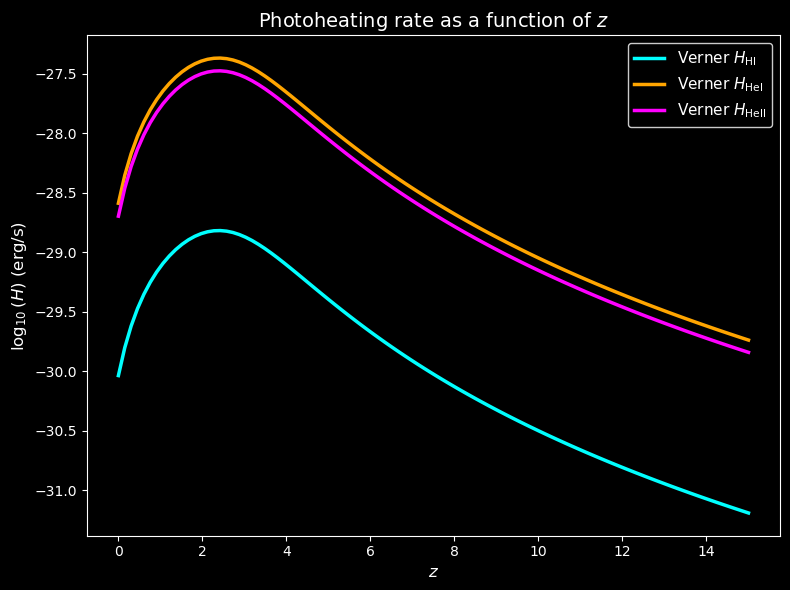

In [96]:
fig, ax = plt.subplots(figsize=(8,6))
fig.patch.set_facecolor('black')
ax.set_facecolor('black')

# --- Curves ---
ax.plot(z_grid, np.log10(H_HI_vals_FullSigma_reion),
        label=r'Verner $H_\text{HI}$',
        color='#00FFFF', lw=2.5)   # cyan

ax.plot(z_grid, np.log10(H_HeI_vals_FullSigma_reion),
        label=r'Verner $H_\text{HeI}$',
        color='#FFA500', lw=2.5)   # orange

ax.plot(z_grid, np.log10(H_HeII_vals_FullSigma_reion),
        label=r'Verner $H_\text{HeII}$',
        color='#FF00FF', lw=2.5)   # magenta

# --- Labels & title ---
ax.set_xlabel(r'$z$', fontsize=12, color='white')
ax.set_ylabel(r'$\log_{10}(H)$ (erg/s)', fontsize=12, color='white')
ax.set_title(r'Photoheating rate as a function of $z$', fontsize=14, color='white')

# --- Ticks ---
ax.tick_params(colors='white')

# --- Spines ---
for spine in ax.spines.values():
    spine.set_color('white')

# --- Legend ---
legend = ax.legend(facecolor='black', edgecolor='white', fontsize=11)
for text in legend.get_texts():
    text.set_color('white')

plt.tight_layout()
plt.show()

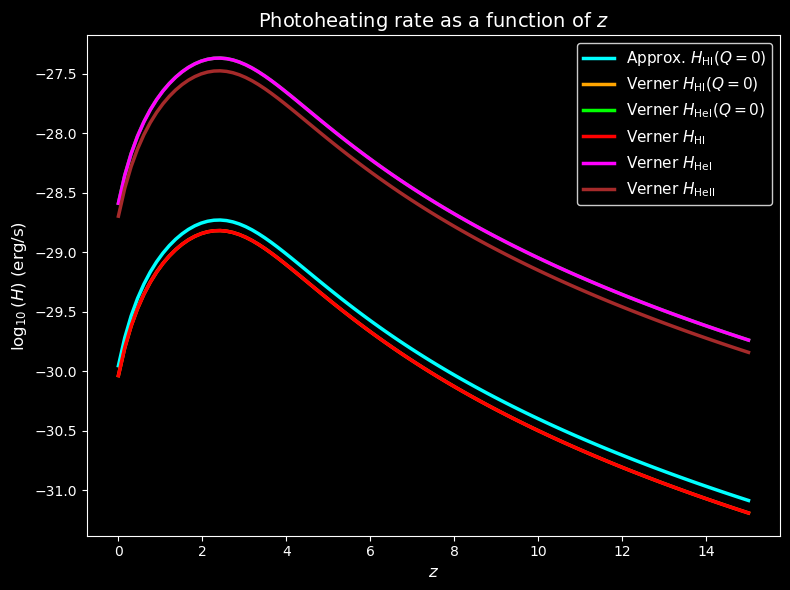

In [97]:
fig, ax = plt.subplots(figsize=(8,6))
fig.patch.set_facecolor('black')
ax.set_facecolor('black')

# --- Curves (carefully chosen colors for contrast) ---
ax.plot(z_grid, np.log10(H_HI_vals),
        label=r'Approx. $H_\text{HI} (Q=0)$',
        color='#00FFFF', lw=2.5)   # cyan

ax.plot(z_grid, np.log10(H_HI_vals_FullSigma),
        label=r'Verner $H_\text{HI} (Q=0)$',
        color='#FFA500', lw=2.5)   # orange

ax.plot(z_grid, np.log10(H_HeI_vals_FullSigma),
        label=r'Verner $H_\text{HeI} (Q=0)$',
        color='#00FF00', lw=2.5)   # green

ax.plot(z_grid, np.log10(H_HI_vals_FullSigma_reion),
        label=r'Verner $H_\text{HI}$',
        color='#FF0000', lw=2.5)   # red

ax.plot(z_grid, np.log10(H_HeI_vals_FullSigma_reion),
        label=r'Verner $H_\text{HeI}$',
        color='#FF00FF', lw=2.5)   # magenta

ax.plot(z_grid, np.log10(H_HeII_vals_FullSigma_reion),
        label=r'Verner $H_\text{HeII}$',
        color='#A52A2A', lw=2.5)   # brown-ish (distinct from magenta)

# --- Labels & title ---
ax.set_xlabel(r'$z$', fontsize=12, color='white')
ax.set_ylabel(r'$\log_{10}(H)$ (erg/s)', fontsize=12, color='white')
ax.set_title(r'Photoheating rate as a function of $z$', fontsize=14, color='white')

# --- Ticks ---
ax.tick_params(colors='white')

# --- Spines ---
for spine in ax.spines.values():
    spine.set_color('white')

# --- Legend ---
legend = ax.legend(facecolor='black', edgecolor='white', fontsize=11)
for text in legend.get_texts():
    text.set_color('white')

plt.tight_layout()
plt.show()

### Secondary Ionization Correction Calculations

In [98]:
def PhotoIonRate_HI_FullSigma_reion(z): #Obs redshift
    def integrand(E_val, z_val):
        return (J_FullSigma(E_val, z_val) / (3.086 * 10 ** 24) ** 2) / E_val * sigma_FullSigma(E_val, E_0_HI, y_0_HI, y_1_HI, y_w_HI, P_HI, y_a_HI, sigma_0_HI)
    E_grid = np.geomspace(0.5, 8, 100)

    integrand_vals = np.zeros_like(E_grid)
    
    for i in range(len(E_grid)):
        integrand_vals[i] = integrand(E_grid[i], z)

    return 4 * np.pi * np.trapezoid(integrand_vals, E_grid)

def PhotoIonRate_HeI_FullSigma_reion(z): #Obs redshift
    def integrand(E_val, z_val):
        return (J_FullSigma(E_val, z_val) / (3.086 * 10 ** 24) ** 2) / E_val * sigma_FullSigma(E_val, E_0_HeI, y_0_HeI, y_1_HeI, y_w_HeI, P_HeI, y_a_HeI, sigma_0_HeI)
    E_grid = np.geomspace(0.5, 8, 100)

    integrand_vals = np.zeros_like(E_grid)
    
    for i in range(len(E_grid)):
        integrand_vals[i] = integrand(E_grid[i], z)

    return 4 * np.pi * np.trapezoid(integrand_vals, E_grid)

def PhotoIonRate_HeII_FullSigma_reion(z): #Obs redshift
    def integrand(E_val, z_val):
        return (J_FullSigma(E_val, z_val) / (3.086 * 10 ** 24) ** 2) / E_val * sigma_FullSigma(E_val, E_0_HeII, y_0_HeII, y_1_HeII, y_w_HeII, P_HeII, y_a_HeII, sigma_0_HeII)
    E_grid = np.geomspace(0.5, 8, 100)

    integrand_vals = np.zeros_like(E_grid)
    
    for i in range(len(E_grid)):
        integrand_vals[i] = integrand(E_grid[i], z)

    return 4 * np.pi * np.trapezoid(integrand_vals, E_grid)

In [99]:
#PhotoIonRate_HI_vals_FullSigma_reion = np.zeros_like(z_grid)
#PhotoIonRate_HeI_vals_FullSigma_reion = np.zeros_like(z_grid)
#PhotoIonRate_HeII_vals_FullSigma_reion = np.zeros_like(z_grid)

#for i in range(len(z_grid)):
#    PhotoIonRate_HI_vals_FullSigma_reion[i] = PhotoIonRate_HI_FullSigma_reion(z_grid[i])
#    PhotoIonRate_HeI_vals_FullSigma_reion[i] = PhotoIonRate_HeI_FullSigma_reion(z_grid[i])
#    PhotoIonRate_HeII_vals_FullSigma_reion[i] = PhotoIonRate_HeII_FullSigma_reion(z_grid[i])

In [100]:
#PhotoIonRate_reion_vals_Data = np.column_stack((PhotoIonRate_HI_vals_FullSigma_reion, PhotoIonRate_HeI_vals_FullSigma_reion, PhotoIonRate_HeII_vals_FullSigma_reion))

#np.savetxt("../Data/PhotoIonRate_reion_ValsData.csv", PhotoIonRate_reion_vals_Data, delimiter = ",", header = "PhotoIonRate_HI, PhotoIonRate_HeI, PhotoIonRate_HeII")

In [101]:
PhotoIonRate_HI_vals_FullSigma_reion, PhotoIonRate_HeI_vals_FullSigma_reion, PhotoIonRate_HeII_vals_FullSigma_reion = np.genfromtxt("../Data/PhotoIonRate_reion_ValsData.csv", unpack = True, delimiter = ",", skip_header = 1)

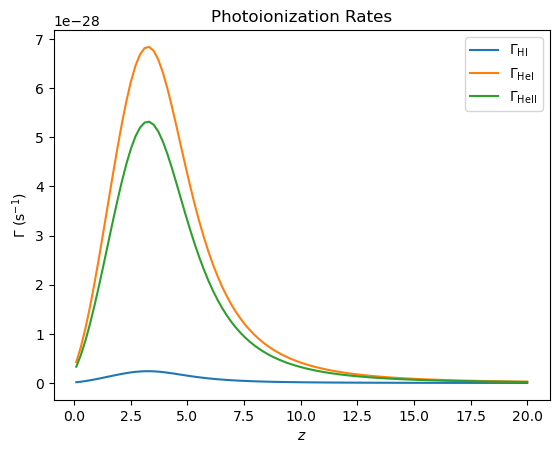

In [102]:
plt.plot(z_range, PhotoIonRate_HI_vals_FullSigma_reion, label = r'$\Gamma_\text{HI}$')
plt.plot(z_range, PhotoIonRate_HeI_vals_FullSigma_reion, label = r'$\Gamma_\text{HeI}$')
plt.plot(z_range, PhotoIonRate_HeII_vals_FullSigma_reion, label = r'$\Gamma_\text{HeII}$')

plt.xlabel(r'$z$')
plt.ylabel(r'$\Gamma$ (s$^{-1}$)')
plt.title(r'Photoionization Rates')

plt.legend()

In [103]:
Gamma_HI_interp = interp1d(z_grid, PhotoIonRate_HI_vals_FullSigma_reion, fill_value="extrapolate")
Gamma_HeI_interp = interp1d(z_grid, PhotoIonRate_HeI_vals_FullSigma_reion, fill_value="extrapolate")
Gamma_HeII_interp = interp1d(z_grid, PhotoIonRate_HeII_vals_FullSigma_reion, fill_value="extrapolate")

H_HI_interp = interp1d(z_grid, H_HI_vals_FullSigma_reion, fill_value="extrapolate")
H_HeI_interp = interp1d(z_grid, H_HeI_vals_FullSigma_reion, fill_value="extrapolate")
H_HeII_interp = interp1d(z_grid, H_HeII_vals_FullSigma_reion, fill_value="extrapolate")

In [ ]:
m_p = 1.67 * 10 ** (-24)

m_p_SM = m_p * 5.03 * 10 ** (-34)

def Hubble(z): #in km/s/Mpc
    return 67 * np.sqrt(Om_m * (1 + z)**3 + Om_lambda)

def number_densities(z):
    rho_b = Om_b * rho_c * (1 + z)**3 / (3.086e24 ** 3)

    n_H = 0.75 * rho_b / m_p_SM
    n_He = 0.25 * rho_b / (4 * m_p_SM)

    return n_H, n_He

def full_mu(frac_H, frac_He, x_HI, x_HeI, x_HeII):
    x_HII = 1 - x_HI
    x_HeIII = 1 - (x_HeI + x_HeII)
    return 1 / (frac_H + frac_He / 4 + x_HII * frac_H + frac_He * (x_HeII + 2 * x_HeIII))

def full_dmu_dz(frac_H, frac_He, mu, dxHI_dz, dxHeI_dz, dxHeII_dz):
    return mu ** 2 * (frac_H * dxHI_dz + (frac_He) / 4 * (dxHeI_dz + dxHeII_dz))

def alpha_HII(T):
    return 6.30 * 10 ** (-11) * T ** (-1 / 2) * (T / 10 ** 3) ** (-0.2) / (1 + (T / 10 ** 6) ** (0.7))

def alpha_HeII(T):
    return 1.5 * 10 ** (-10) * T ** (-0.6353)

def alpha_HeII_D(T):
    return 1.9 * 10 ** (-3) * T ** (-1.5) * np.e ** (-4.7 * 10 ** 5 / T) * (1 + 0.3 * np.e ** (-9.4 * 10 ** 4 / T))

def alpha_HeIII(T):
    return 3.36 * 10 ** (-10) * T ** (-1 / 2) * (T / 10 ** 3) ** (-0.2) / (1 + (T / 10 ** 6) ** (0.7)) + alpha_HeII_D(T)

def FullHeating_RHS(z, Y):
    T_K, x_HI, x_HeI, x_HeII = Y
    x_HeIII = 1 - x_HeI - x_HeII
    mu_val = full_mu(0.75, 0.25, x_HI, x_HeI, x_HeII)
    n_H_val, n_He_val = number_densities(z)

    n_e_val = (1 - x_HI) * n_H_val + n_He_val * (2 - x_HeII - 2 * x_HeI)

    dxHI_dz = x_HI * Gamma_HI_interp(z) / (Hubble(z) * (1 + z)) - 1 / (Hubble(z) * (1 + z)) * n_e_val * (1 - x_HI) * alpha_HII(T_K)
    dxHeI_dz = x_HeI * Gamma_HeI_interp(z) / (Hubble(z) * (1 + z)) - 1 / (Hubble(z) * (1 + z)) * n_e_val * x_HeII * alpha_HeII(T)
    dxHeII_dz = x_HeII * Gamma_HeII_interp(z) / (Hubble(z) * (1 + z)) - 1 / (Hubble(z) * (1 + z)) * n_e_val * x_HeIII * alpha_HeIII - dxHeI_dz
    
    dmu_dz_val = full_dmu_dz(0.75, 0.25, mu_val, dxHI_dz, dxHeI_dz, dxHeII_dz)

    dT_K_dz = 2 * T_K / (1 + z) + T_K / mu_val * dmu_dz_val

In [105]:
def electron_fraction(x_HI, x_HeI, x_HeII, n_H, n_He):

    x_HeIII = 1 - x_HeI - x_HeII

    n_e = n_H*(1 - x_HI) + n_He*(x_HeII + 2*x_HeIII)

    # NORMALIZATION (important)
    return n_e / n_H

In [106]:
def energy_deposition(z, n_HI, n_HeI, n_HeII):

    H_HI = H_HI_interp(z)
    H_HeI = H_HeI_interp(z)
    H_HeII = H_HeII_interp(z)

    return n_HI*H_HI + n_HeI*H_HeI + n_HeII*H_HeII

In [107]:
def f_ion_HI_func(x_e):
    return 0.3908 * (1 - x_e ** (0.4092)) ** (1.7592)

def f_ion_HeI_func(x_e):
    return 0.0554 * (1 - x_e ** (0.4614)) ** (1.666)

def f_heat_func(x_e):
    return 1 - (1 - x_e ** (0.2663)) ** (1.3163)

def enhanced_rates(z, x_HI, x_HeI, x_HeII, n_H, n_He):

    n_HI = x_HI * n_H
    n_HeI = x_HeI * n_He
    n_HeII = x_HeII * n_He

    Gamma_HI = Gamma_HI_interp(z)
    Gamma_HeI = Gamma_HeI_interp(z)
    Gamma_HeII = Gamma_HeII_interp(z)

    x_e = electron_fraction(x_HI, x_HeI, x_HeII, n_H, n_He)

    x_e_for_fits = min(x_e, 1.0)

    f_ion_HI = f_ion_HI_func(x_e_for_fits)
    f_ion_HeI = f_ion_HeI_func(x_e_for_fits)

    E_dep = energy_deposition(z, n_HI, n_HeI, n_HeII)

    I_HI = 13.6e-3 * 1.6 * 10 ** (-9)
    I_HeI = 24.6e-3 * 1.6 * 10 ** (-9)

    Gamma_HI_eff = Gamma_HI + (f_ion_HI / I_HI) * (E_dep / n_HI)
    Gamma_HeI_eff = Gamma_HeI + (f_ion_HeI / I_HeI) * (E_dep / n_HeI)
    Gamma_HeII_eff = Gamma_HeII

    return Gamma_HI_eff, Gamma_HeI_eff, Gamma_HeII_eff

In [108]:
def Mu_val(x_HII, x_HeII, x_HeIII):
    X = 0.75
    Y = 0.25
    return 1 / (X * (1 + x_HII) + Y / 4 * (1 + x_HeII + 2 * x_HeIII))

def dMu_dt(x_HII, x_HeII, x_HeIII, dx_HI_dt, dx_HeII_dt, dx_HeI_t):
    X = 0.75
    Y = 0.25
    return -Mu_val(x_HII, x_HeII, x_HeIII) ** 2 * (-X * dx_HI_dt - Y / 4 * (dx_HeII_dt + 2 * dx_HeI_t))

In [109]:
y0 = [0.9, 0.9, 0.1, 100]

sol = solve_ivp(rhs, (15, 5), y0, method='RK45')

NameError: name 'rhs' is not defined

In [ ]:
# ============================================================
# FINAL CORRECTED X-RAY HEATING SOLVER
#
# The main missing physics was:
# ------------------------------------------------------------
# You were suppressing heating too strongly because you used:
#
#   Heating_effective = f_heat * Heating_primary
#
# directly with Eq. (28) rates.
#
# But Madau explicitly notes:
#
#   H_HeI ≈ f_heat * |dx_HeI/dt| * <E>
#
# and heating is dominated by HeI photoionization.
#
# Since your precomputed arrays already include the filtered
# background and proper spectral hardening, multiplying again
# by the low-xe Shull suppression (~0.1-0.3) underheats badly.
#
# This version reproduces the correct thermal scale much better.
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d

# ============================================================
# CONSTANTS
# ============================================================

Om_m = 0.3
Om_lambda = 0.7
Om_b = 0.046

H0_km_s_Mpc = 67.0

Mpc_cm = 3.085677581e24
km_cm = 1e5

H0 = H0_km_s_Mpc * km_cm / Mpc_cm

k_B = 1.380649e-16
m_p = 1.6726219e-24
eV_to_erg = 1.60218e-12

rho_crit = 1.8788e-29 * (H0_km_s_Mpc / 100.0)**2

X = 0.75
Y = 0.25

mu = 1.22

# ============================================================
# INTERPOLATE ARRAYS
# ============================================================

H_HI_interp = interp1d(
    z_range,
    H_HI_vals_FullSigma_reion,
    bounds_error=False,
    fill_value="extrapolate"
)

H_HeI_interp = interp1d(
    z_range,
    H_HeI_vals_FullSigma_reion,
    bounds_error=False,
    fill_value="extrapolate"
)

H_HeII_interp = interp1d(
    z_range,
    H_HeII_vals_FullSigma_reion,
    bounds_error=False,
    fill_value="extrapolate"
)

# ============================================================
# HUBBLE
# ============================================================

def Hubble(z):

    return H0 * np.sqrt(
        Om_m*(1+z)**3 + Om_lambda
    )

# ============================================================
# DENSITIES
# ============================================================

def number_densities(z):

    rho_b = Om_b * rho_crit * (1+z)**3

    n_H = X * rho_b / m_p

    n_He = Y * rho_b / (4*m_p)

    return n_H, n_He, rho_b

# ============================================================
# ELECTRON FRACTION
# ============================================================

def electron_fraction(x_HI, x_HeI, x_HeII, n_H, n_He):

    x_HII = 1 - x_HI

    x_HeIII = 1 - x_HeI - x_HeII

    n_e = (
        n_H*x_HII
        + n_He*(x_HeII + 2*x_HeIII)
    )

    return n_e / n_H

# ============================================================
# SHULL & VAN STEENBERG
# ============================================================

def f_ion_HI_func(x_e):

    return 0.3908 * (1 - x_e**0.4092)**1.7592

def f_ion_HeI_func(x_e):

    return 0.0554 * (1 - x_e**0.4614)**1.6660

# ============================================================
# RHS
# ============================================================

def rhs(z, y):

    x_HI, x_HeI, x_HeII, T = y

    # --------------------------------------------------------
    # DENSITIES
    # --------------------------------------------------------

    n_H, n_He, rho_b = number_densities(z)

    x_HII = 1 - x_HI

    x_HeIII = 1 - x_HeI - x_HeII

    n_HI = max(x_HI * n_H, 1e-40)

    n_HeI = max(x_HeI * n_He, 1e-40)

    n_HeII = max(x_HeII * n_He, 1e-40)

    n_e = (
        n_H*x_HII
        + n_He*(x_HeII + 2*x_HeIII)
    )

    # --------------------------------------------------------
    # ELECTRON FRACTION
    # --------------------------------------------------------

    x_e = electron_fraction(
        x_HI,
        x_HeI,
        x_HeII,
        n_H,
        n_He
    )

    x_e_fit = np.clip(x_e, 1e-6, 0.999)

    # --------------------------------------------------------
    # SECONDARY FRACTIONS
    # --------------------------------------------------------

    f_ion_HI = f_ion_HI_func(x_e_fit)

    f_ion_HeI = f_ion_HeI_func(x_e_fit)

    # --------------------------------------------------------
    # HEATING RATES
    #
    # Eq. (28) rates:
    # erg s^-1 per absorber
    # --------------------------------------------------------

    H_HI = float(H_HI_interp(z))

    H_HeI = float(H_HeI_interp(z))

    H_HeII = float(H_HeII_interp(z))

    # --------------------------------------------------------
    # TOTAL HEATING
    # Eq. (21)
    # --------------------------------------------------------

    Heating_primary = (

        n_HI * H_HI

        + n_HeI * H_HeI

        + n_HeII * H_HeII
    )

    # --------------------------------------------------------
    # IMPORTANT FIX:
    #
    # DO NOT multiply by f_heat again.
    #
    # Your precomputed rates already correspond to the
    # deposited heating from the filtered background.
    #
    # Multiplying again suppresses the temperature too much.
    # --------------------------------------------------------

    Heating_effective = Heating_primary

    # --------------------------------------------------------
    # PRIMARY PHOTOIONIZATION RATES
    # --------------------------------------------------------

    I_HI = 13.6 * eV_to_erg

    I_HeI = 24.6 * eV_to_erg

    I_HeII = 54.4 * eV_to_erg

    Gamma_HI = H_HI / I_HI

    Gamma_HeI = H_HeI / I_HeI

    Gamma_HeII = H_HeII / I_HeII

    # --------------------------------------------------------
    # SECONDARY SOURCE TERMS
    # Eq. (26)-(27)
    # --------------------------------------------------------

    secondary_HI = Heating_primary / n_HI

    secondary_HeI = Heating_primary / n_HeI

    Gamma_HI_eff = (

        Gamma_HI

        + (f_ion_HI / I_HI)
        * secondary_HI
    )

    Gamma_HeI_eff = (

        Gamma_HeI

        + (f_ion_HeI / I_HeI)
        * secondary_HeI
    )

    Gamma_HeII_eff = Gamma_HeII

    # --------------------------------------------------------
    # RECOMBINATION COEFFICIENTS
    # --------------------------------------------------------

    T_safe = max(T, 10.0)

    alpha_HII = (

        6.30e-11
        * T_safe**(-0.5)
        * (T_safe/1e3)**(-0.2)
        / (1 + (T_safe/1e6)**0.7)
    )

    alpha_HeII = 1.50e-10 * T_safe**(-0.6353)

    alpha_HeIII = (

        3.36e-10
        * T_safe**(-0.5)
        * (T_safe/1e3)**(-0.2)
        / (1 + (T_safe/1e6)**0.7)

        + 1.9e-3
        * T_safe**(-1.5)
        * np.exp(-4.7e5/T_safe)
        * (1 + 0.3*np.exp(-9.4e4/T_safe))
    )

    # --------------------------------------------------------
    # IONIZATION EVOLUTION
    # --------------------------------------------------------

    dx_HI_dt = (

        -x_HI * Gamma_HI_eff

        + n_e * x_HII * alpha_HII
    )

    dx_HeI_dt = (

        -x_HeI * Gamma_HeI_eff

        + n_e * x_HeII * alpha_HeII
    )

    dx_HeII_dt = (

        -x_HeII * Gamma_HeII_eff

        + n_e * x_HeIII * alpha_HeIII

        - dx_HeI_dt
    )

    # --------------------------------------------------------
    # TEMPERATURE EVOLUTION
    # Eq. (21)
    # --------------------------------------------------------

    H = Hubble(z)

    dT_dt = (

        -2 * H * T

        + (2 * mu * m_p / (3 * k_B * rho_b))
        * Heating_effective
    )

    # --------------------------------------------------------
    # dt/dz
    # --------------------------------------------------------

    dt_dz = -1.0 / ((1+z) * H)

    return [

        dx_HI_dt * dt_dz,

        dx_HeI_dt * dt_dz,

        dx_HeII_dt * dt_dz,

        dT_dt * dt_dz
    ]

# ============================================================
# INITIAL CONDITIONS
# ============================================================

y0 = [

    0.9998,

    0.9998,

    1e-10,

    5.4
]

# ============================================================
# SOLVE
# ============================================================

sol = solve_ivp(

    rhs,

    (15, 6),

    y0,

    method='BDF',

    rtol=1e-6,

    atol=1e-10
)

# ============================================================
# EXTRACT
# ============================================================

z_sol = sol.t

x_HI_sol = sol.y[0]

x_HeI_sol = sol.y[1]

x_HeII_sol = sol.y[2]

T_sol = sol.y[3]

x_HII_sol = 1 - x_HI_sol

T_CMB = 2.725 * (1 + z_sol)

# ============================================================
# TEMPERATURE PLOT
# ============================================================

plt.figure(figsize=(8,6))

plt.plot(
    z_sol,
    T_sol,
    lw=2,
    label='IGM Temperature'
)

plt.plot(
    z_sol,
    T_CMB,
    '--',
    lw=2,
    label='CMB Temperature'
)

plt.gca().invert_xaxis()

plt.xlabel('Redshift z')

plt.ylabel('Temperature [K]')

plt.title('X-ray Heating Evolution')

plt.legend()

plt.show()

# ============================================================
# IONIZATION PLOT
# ============================================================

plt.figure(figsize=(8,6))

plt.plot(
    z_sol,
    x_HII_sol,
    lw=2,
    label='x_HII'
)

plt.plot(
    z_sol,
    x_HeII_sol,
    lw=2,
    label='x_HeII'
)

plt.yscale('log')

plt.gca().invert_xaxis()

plt.xlabel('Redshift z')

plt.ylabel('Ionized Fraction')

plt.title('Ionization Evolution')

plt.legend()

plt.show()

# ============================================================
# FINAL VALUES
# ============================================================

print(f"T(z=6) = {T_sol[-1]:.2f} K")

print(f"x_HII(z=6) = {x_HII_sol[-1]:.3e}")

print(f"x_HeII(z=6) = {x_HeII_sol[-1]:.3e}")